# Modelo Financiero Integral con IA para Apple Inc. - Notebook Completo Introducción

## Autores

**Grupo 6**

- Javier Molina Van Geel
- David Novegil Ferradás
- José Andrés Pizarro Gascón

---

Este notebook desarrolla un modelo integral de predicción financiera que combina análisis de sentimiento, indicadores técnicos y datos fundamentales para predecir la dirección del precio de las acciones de Apple Inc. utilizando técnicas avanzadas de machine learning.

## 0. Parametría

Las siguientes variables se reusan a lo largo de todo el notebook

In [ ]:
fecha_inicio = "01-01-2020"
fecha_fin = "31-12-2025"
ticker = "AAPL"

## 1. Recolección de Datos de Sentimiento


## 1.1. Obtención de sentimientos de medios de comunicación

Ejecutamos la siguiente query en Google Bigquery para obtener el sentimiento de las noticias de `AAPL`a lo largo de todo el periodo de análisis.

Usaremos Google BigQuery para obtener y persistir los datos de la base de datos pública GDELT. Las queries en este servicio tienen un alto coste, y la capa gratuita solo nos permite escanear 1TB de datos.

Usaremos la siguiente query de SQL BigQuery para obtener los datos.

```sql
SELECT
    DATE(_PARTITIONTIME) AS fecha,
    COUNT(1) AS volumen_noticias,
    -- 1. Sentimiento Promedio (Tono general: positivo - negativo)
    ROUND(AVG(SAFE_CAST(SPLIT(v2tone, ',')[SAFE_OFFSET(0)] AS FLOAT64)), 3) AS sentimiento_promedio,
    -- 2. Puntuación Positiva (Porcentaje de palabras positivas en el texto)
    ROUND(AVG(SAFE_CAST(SPLIT(v2tone, ',')[SAFE_OFFSET(1)] AS FLOAT64)), 3) AS puntuacion_positiva,
    -- 3. Puntuación Negativa (Porcentaje de palabras negativas en el texto)
    ROUND(AVG(SAFE_CAST(SPLIT(v2tone, ',')[SAFE_OFFSET(2)] AS FLOAT64)), 3) AS puntuacion_negativa,
    -- 4. Polaridad Promedio (Carga emocional total / subjetividad de los textos)
    ROUND(AVG(SAFE_CAST(SPLIT(v2tone, ',')[SAFE_OFFSET(3)] AS FLOAT64)), 3) AS polaridad_promedio,
    -- 5. Volatilidad / Desviación Estándar (Mide si hay mucha división de opiniones en el mismo día)
    ROUND(STDDEV_SAMP(SAFE_CAST(SPLIT(v2tone, ',')[SAFE_OFFSET(0)] AS FLOAT64)), 3) AS volatilidad_sentimiento,
    -- 6. Autorreferencias (Mide el porcentaje de pronombres en primera persona)
    ROUND(AVG(SAFE_CAST(SPLIT(v2tone, ',')[SAFE_OFFSET(4)] AS FLOAT64)), 3) AS uso_primera_persona
FROM
    `gdelt-bq.gdeltv2.gkg_partitioned`
WHERE
    -- Filtro crítico de partición para optimizar costes de consulta
    _PARTITIONTIME BETWEEN TIMESTAMP(@start_date) AND TIMESTAMP(@end_date)
    -- Filtro de búsqueda de la organización
    AND (LOWER(v2organizations) LIKE @keyword)
    -- Filtrar para evitar duplicados por traducciones automáticas
    AND translationinfo IS NULL
GROUP BY
    fecha
ORDER BY
    fecha ASC
```

La descripción de los campos es la siguiente

| Campo | Tipo de Dato | Origen en GDELT | Descripción y Rango |
|:------------------------|:-------------|:------------------|:----------------------------------------------------------------------------------------------------------------------|
| fecha | DATE | _PARTITIONTIME | Fecha en formato YYYY-MM-DD que identifica el día de publicación de las noticias. |
| volumen_noticias | INTEGER | COUNT(1) | Cantidad de artículos que mencionan la palabra clave ("Apple") en ese día. |
| sentimiento_promedio | FLOAT64 | v2tone[0] | El "Tono" medio de las noticias del día. Rango habitual: -10 a +10. |
| puntuacion_positiva | FLOAT64 | v2tone[1] | Porcentaje promedio de palabras de carácter positivo en los textos. |
| puntuacion_negativa | FLOAT64 | v2tone[2] | Porcentaje promedio de palabras de carácter negativo en los textos. |
| polaridad_promedio | FLOAT64 | v2tone[3] | Porcentaje de palabras con carga emocional (fuerza de la opinión). |
| volatilidad_sentimiento | FLOAT64 | STDDEV_SAMP(v2tone[0]) | Desviación estándar del sentimiento de ese día. Mide la polarización. |
| uso_primera_persona | FLOAT64 | v2tone[4] | Porcentaje de palabras autorreferenciales (pronombres en primera persona). |


Por ahorro de costes, almacenamos los ficheros en un directorio de Google Drive, el cual cargaremos para realizar este ejercicio.



In [ ]:
#  Importación de todas las librerías necesarias
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# Configuración de visualización
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [ ]:
# Definir la ruta a la carpeta donde están tus CSVs de sentimiento
# ¡ADVERTENCIA! Asegúrate de que esta ruta sea correcta para tu configuración de Google Drive.
sentiment_data_path = "/content/gdrive/MyDrive/Personal/Formaciones/UNIR-IA_Finanzas/TEMA_7/Practica_2/noticias_sentimiento/"

In [ ]:
import matplotlib.pyplot as plt
import os
from google.colab import drive

print("☁️ Montando Google Drive...")
drive.mount("/content/gdrive")

# Lista para almacenar DataFrames de cada CSV
all_sentiment_dfs = []

print(f"📂 Leyendo archivos CSV de: {sentiment_data_path}")

try:
    # Iterar sobre los archivos en la carpeta
    for filename in os.listdir(sentiment_data_path):
        if filename.endswith(".csv"):
            file_path = os.path.join(sentiment_data_path, filename)
            try:
                df_temp = pd.read_csv(file_path)
                all_sentiment_dfs.append(df_temp)
                print(f"  ✅ Leído: {filename} ({len(df_temp)} filas)")
            except Exception as e:
                print(f"  ❌ Error al leer {filename}: {e}")

    if not all_sentiment_dfs:
        raise ValueError("No se encontraron archivos CSV para cargar.")

    # Concatenar todos los DataFrames
    df_sentimiento = pd.concat(all_sentiment_dfs, ignore_index=True)

    # Procesar el DataFrame unificado
    df_sentimiento["fecha"] = pd.to_datetime(df_sentimiento["fecha"])
    df_sentimiento = df_sentimiento.sort_values("fecha").drop_duplicates(
        subset=["fecha"]
    )
    df_sentimiento = df_sentimiento.set_index("fecha")
    df_sentimiento = df_sentimiento.rename_axis(
        "Date"
    )  # Rename the index from 'fecha' to 'Date'
except Exception as e:
    print(f"❌ Error general al cargar datos de sentimiento: {e}")
    print(
        "Asegúrate de que la ruta de Google Drive sea correcta y los archivos CSV existan y tengan el formato esperado."
    )
    print(
        "Continuando con los datos de sentimiento sintéticos para el resto del notebook."
    )
    raise

☁️ Montando Google Drive...
Mounted at /content/gdrive
📂 Leyendo archivos CSV de: /content/gdrive/MyDrive/Personal/Formaciones/UNIR-IA_Finanzas/TEMA_7/Practica_2/noticias_sentimiento/
  ✅ Leído: gdelt_2020001-20261231.csv (2327 filas)


In [ ]:
display(df_sentimiento)

,volumen_noticias,sentimiento_promedio,puntuacion_positiva,puntuacion_negativa,polaridad_promedio,volatilidad_sentimiento,uso_primera_persona
Date,,,,,,,
2020-01-01,111,-1.022,2.360,3.381,5.741,3.125,22.523
2020-01-02,319,0.109,2.381,2.272,4.653,2.470,22.716
2020-01-03,311,-0.434,2.338,2.773,5.111,2.696,23.361
2020-01-04,124,-0.275,2.507,2.782,5.289,2.975,21.719
2020-01-05,99,0.779,3.425,2.646,6.071,3.125,22.676
...,...,...,...,...,...,...,...
2026-05-28,153,0.743,3.097,2.353,5.450,2.893,22.776
2026-05-29,117,-1.202,2.674,3.876,6.550,4.063,22.428
2026-05-30,66,0.983,3.698,2.714,6.412,3.895,22.072


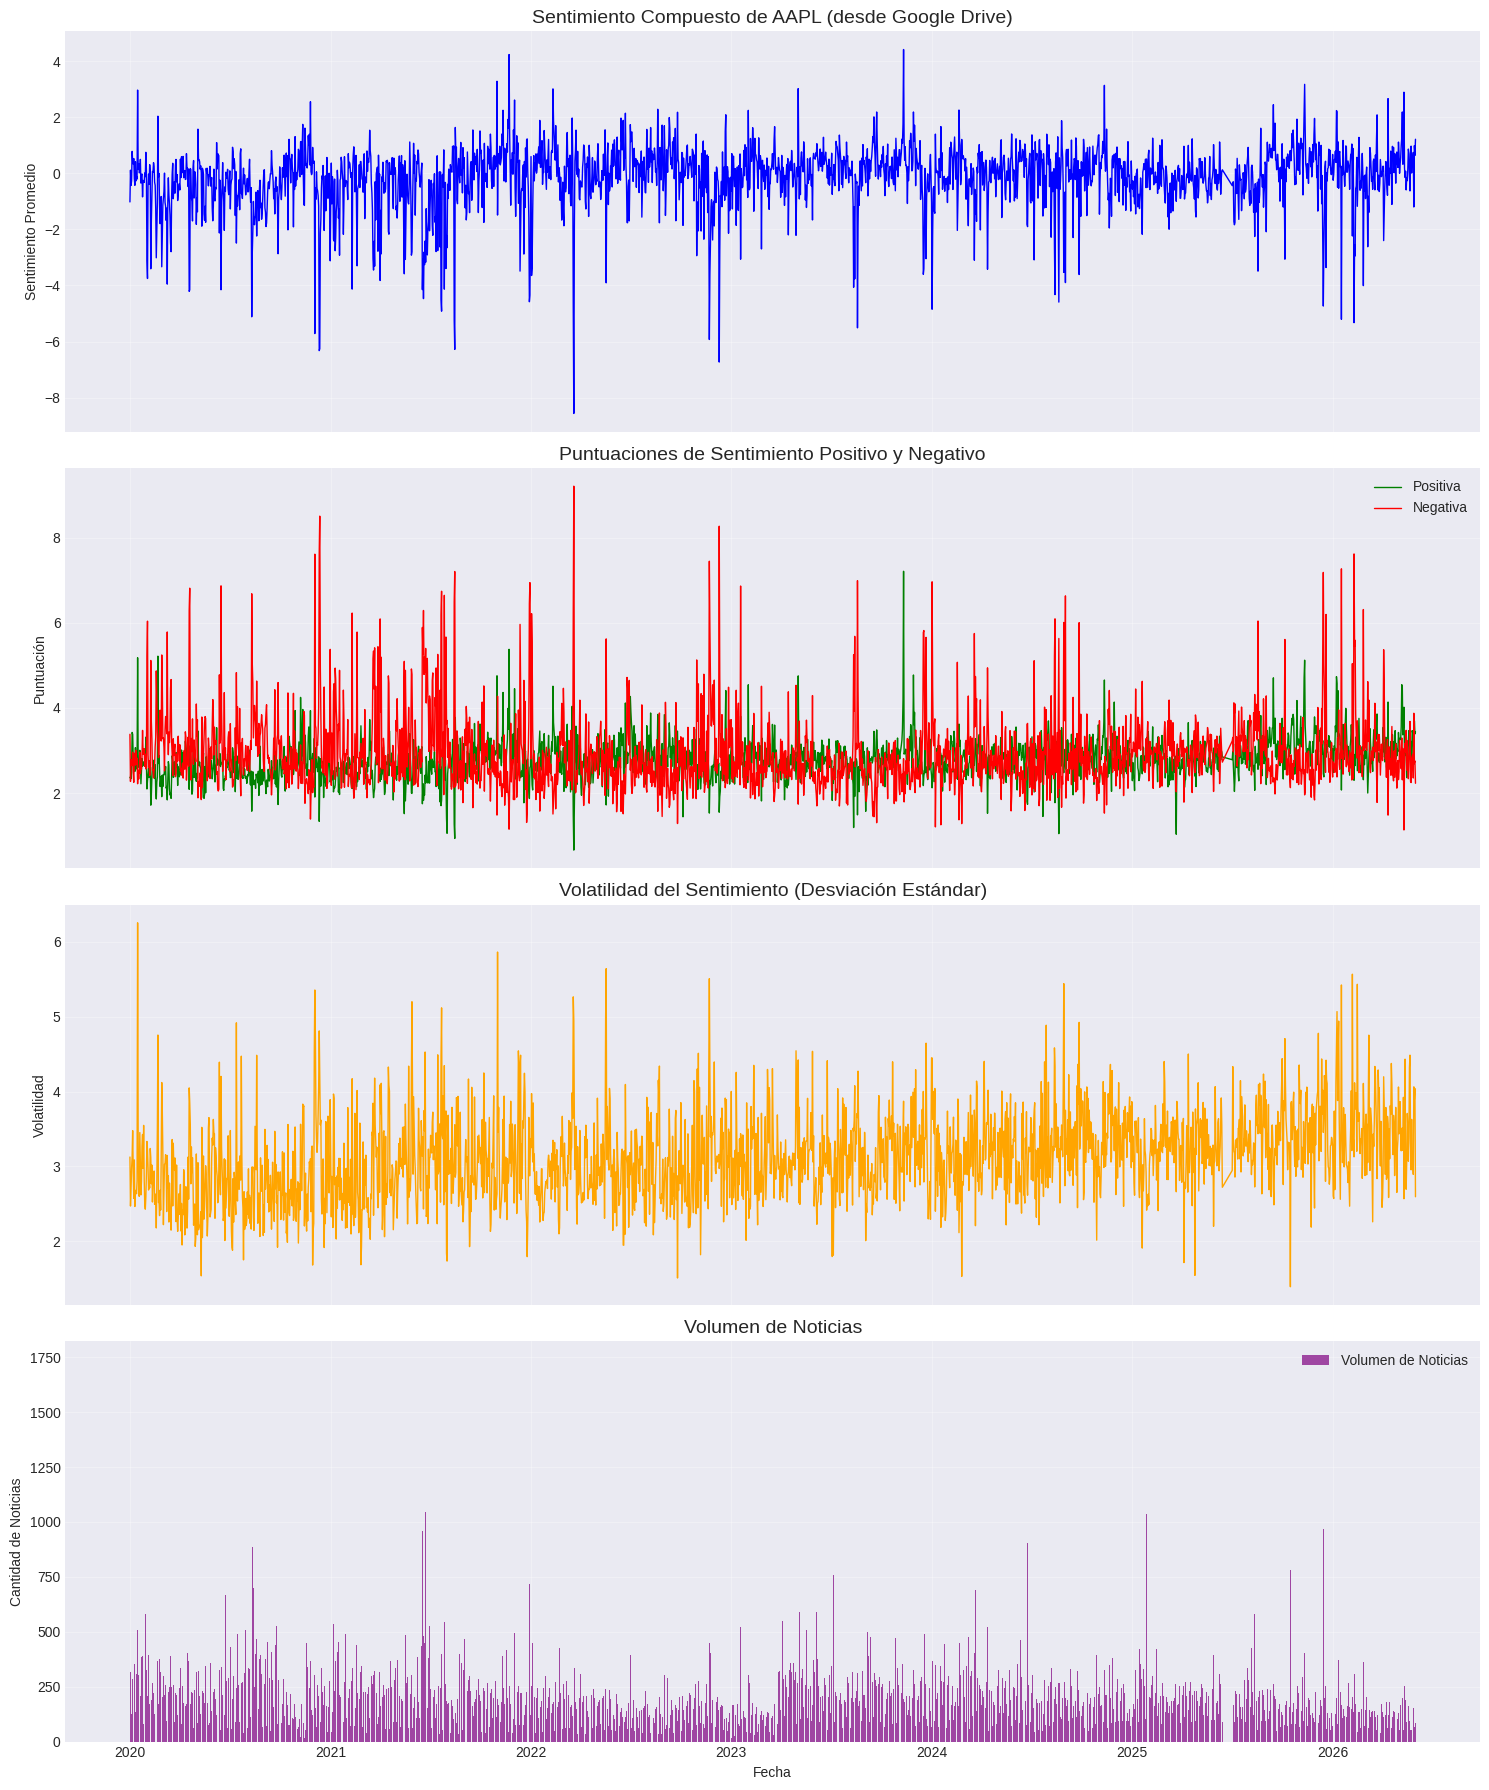

In [ ]:
# Visualización de los datos cargados con más métricas
fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)

# 1. Sentimiento Compuesto
axes[0].plot(
    df_sentimiento.index,
    df_sentimiento["sentimiento_promedio"],
    color="blue",
    linewidth=1,
)
axes[0].set_title(
    f"Sentimiento Compuesto de {ticker.upper()} (desde Google Drive)", fontsize=14
)
axes[0].set_ylabel("Sentimiento Promedio")
axes[0].grid(True, alpha=0.3)

# 2. Puntuaciones Positiva y Negativa
axes[1].plot(
    df_sentimiento.index,
    df_sentimiento["puntuacion_positiva"],
    color="green",
    linewidth=1,
    label="Positiva",
)
axes[1].plot(
    df_sentimiento.index,
    df_sentimiento["puntuacion_negativa"],
    color="red",
    linewidth=1,
    label="Negativa",
)
axes[1].set_title("Puntuaciones de Sentimiento Positivo y Negativo", fontsize=14)
axes[1].set_ylabel("Puntuación")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Volatilidad del Sentimiento
axes[2].plot(
    df_sentimiento.index,
    df_sentimiento["volatilidad_sentimiento"],
    color="orange",
    linewidth=1,
)
axes[2].set_title("Volatilidad del Sentimiento (Desviación Estándar)", fontsize=14)
axes[2].set_ylabel("Volatilidad")
axes[2].grid(True, alpha=0.3)

# 4. Volumen de Noticias
axes[3].bar(
    df_sentimiento.index,
    df_sentimiento["volumen_noticias"],
    color="purple",
    alpha=0.7,
    label="Volumen de Noticias",
)
axes[3].set_title("Volumen de Noticias", fontsize=14)
axes[3].set_xlabel("Fecha")
axes[3].set_ylabel("Cantidad de Noticias")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

## 1.2 Obtención de datos de VIX

Usaremos Yahoo Finance para la obtención de esta información

In [ ]:
# Celda 3: Descarga y análisis del VIX
# VIX es el índice de volatilidad del mercado (índice del miedo)
print("📈 Descargando datos del VIX...")

# Usar las variables fecha_inicio y fecha_fin
df_vix_data = yf.download(
    "^VIX",
    start=datetime.strptime(fecha_inicio, "%d-%m-%Y").strftime("%Y-%m-%d"),
    end=datetime.strptime(fecha_fin, "%d-%m-%Y").strftime("%Y-%m-%d"),
)
df_vix_data = df_vix_data.droplevel("Ticker", axis=1)  # eliminamos multiindex
df_vix_data = df_vix_data[["Close"]].rename(columns={"Close": "VIX"})


# Categorizar niveles de VIX
def categorize_vix(vix_value):
    if vix_value < 20:
        return "Bajo"
    elif vix_value < 30:
        return "Moderado"
    elif vix_value < 40:
        return "Alto"
    else:
        return "Muy Alto"


df_vix_data["VIX_Category"] = df_vix_data["VIX"].apply(categorize_vix)

display(df_vix_data)

📈 Descargando datos del VIX...


[*********************100%***********************]  1 of 1 completed


Price,VIX,VIX_Category
Date,,
2020-01-02,12.47,Bajo
2020-01-03,14.02,Bajo
2020-01-06,13.85,Bajo
2020-01-07,13.79,Bajo
2020-01-08,13.45,Bajo
...,...,...
2025-12-23,14.00,Bajo
2025-12-24,13.47,Bajo
2025-12-26,13.60,Bajo


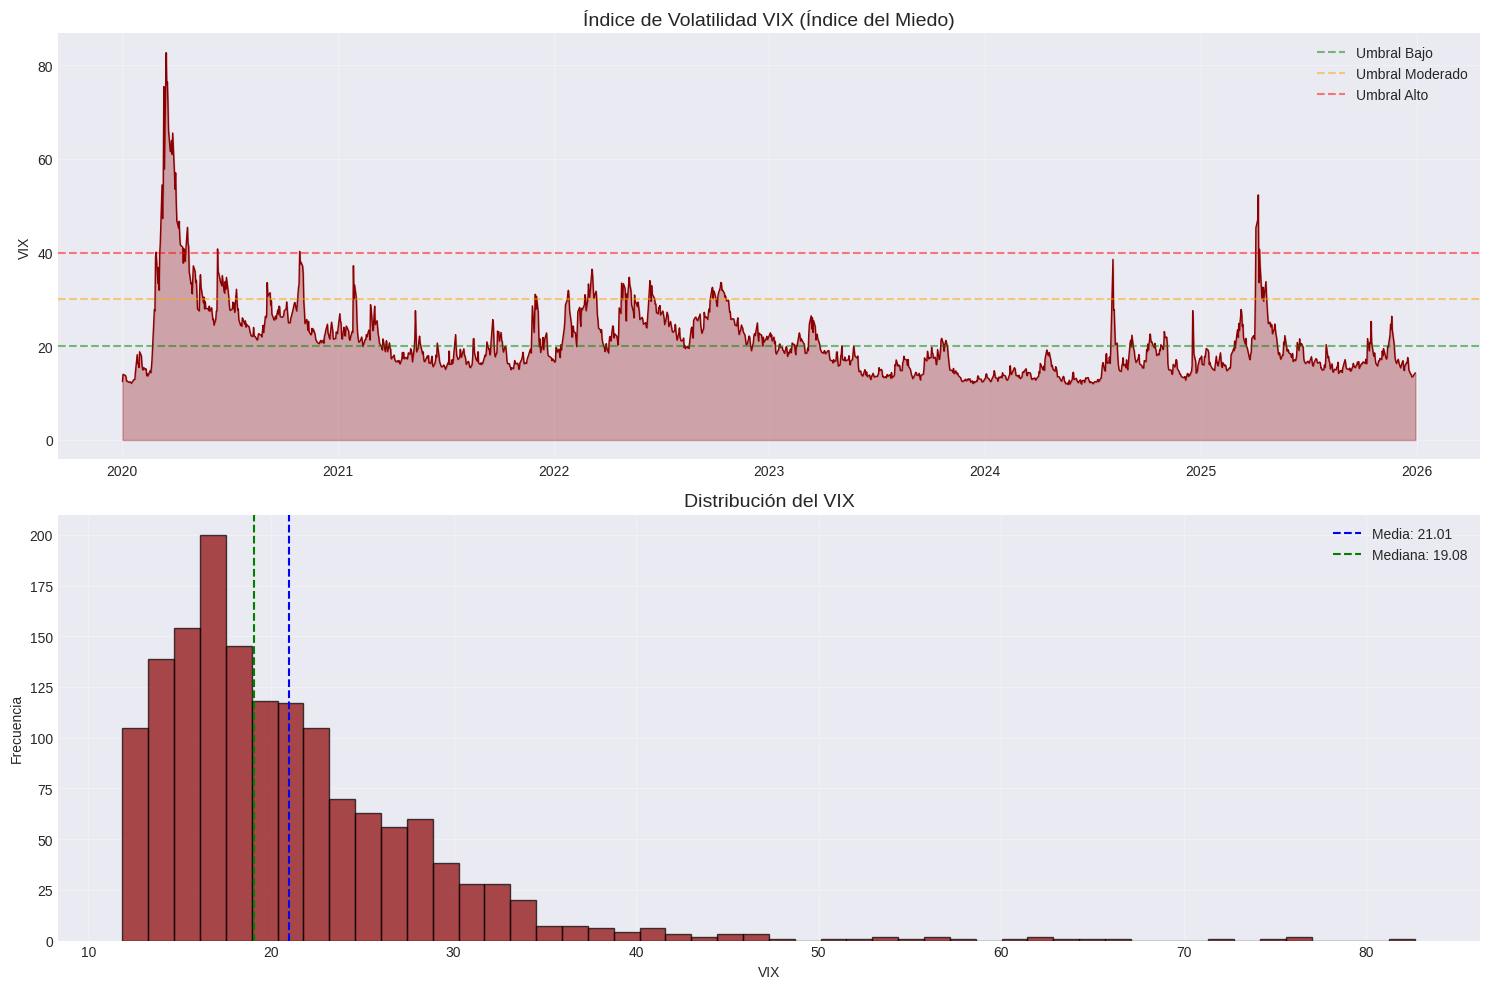


📊 Distribución de Categorías VIX:
Bajo: 839 días (55.7%)
Moderado: 521 días (34.6%)
Alto: 108 días (7.2%)
Muy Alto: 39 días (2.6%)


In [ ]:
# Visualización del VIX
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Gráfico 1: Serie temporal del VIX
ax1 = axes[0]
ax1.plot(df_vix_data.index, df_vix_data["VIX"], color="darkred", linewidth=1)
ax1.axhline(y=20, color="green", linestyle="--", alpha=0.5, label="Umbral Bajo")
ax1.axhline(y=30, color="orange", linestyle="--", alpha=0.5, label="Umbral Moderado")
ax1.axhline(y=40, color="red", linestyle="--", alpha=0.5, label="Umbral Alto")
ax1.fill_between(df_vix_data.index, 0, df_vix_data["VIX"], alpha=0.3, color="darkred")
ax1.set_title("Índice de Volatilidad VIX (Índice del Miedo)", fontsize=14)
ax1.set_ylabel("VIX")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución del VIX
ax2 = axes[1]
df_vix_data["VIX"].hist(bins=50, ax=ax2, color="darkred", alpha=0.7, edgecolor="black")
ax2.axvline(
    x=df_vix_data["VIX"].mean(),
    color="blue",
    linestyle="--",
    label=f"Media: {df_vix_data['VIX'].mean():.2f}",
)
ax2.axvline(
    x=df_vix_data["VIX"].median(),
    color="green",
    linestyle="--",
    label=f"Mediana: {df_vix_data['VIX'].median():.2f}",
)
ax2.set_title("Distribución del VIX", fontsize=14)
ax2.set_xlabel("VIX")
ax2.set_ylabel("Frecuencia")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de categorías
vix_category_counts = df_vix_data["VIX_Category"].value_counts()
print("\n📊 Distribución de Categorías VIX:")
for category, count in vix_category_counts.items():
    percentage = (count / len(df_vix_data)) * 100
    print(f"{category}: {count} días ({percentage:.1f}%)")

## 2. Carga de Datos Históricos y Cálculo de Indicadores Técnicos

## 2.1 Carga de datos históricos

In [ ]:
# Celda 4: Descarga de datos históricos de Apple
print("🍎 Descargando datos históricos de Apple Inc...")

# Descargar datos
df_stock_data = yf.download(
    ticker,
    start=datetime.strptime(fecha_inicio, "%d-%m-%Y").strftime("%Y-%m-%d"),
    end=datetime.strptime(fecha_fin, "%d-%m-%Y").strftime("%Y-%m-%d"),
)
df_stock_data = df_stock_data.droplevel("Ticker", axis=1)  # eliminamos multiindex
display(df_stock_data)

🍎 Descargando datos históricos de Apple Inc...


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200
...,...,...,...,...,...
2025-12-23,271.854919,271.994674,269.060124,270.337749,29642000
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600
2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800



📊 Información del Dataset:
Período: 2020-01-02 a 2025-12-30
Total de días de trading: 1507
Años de datos: 6.0


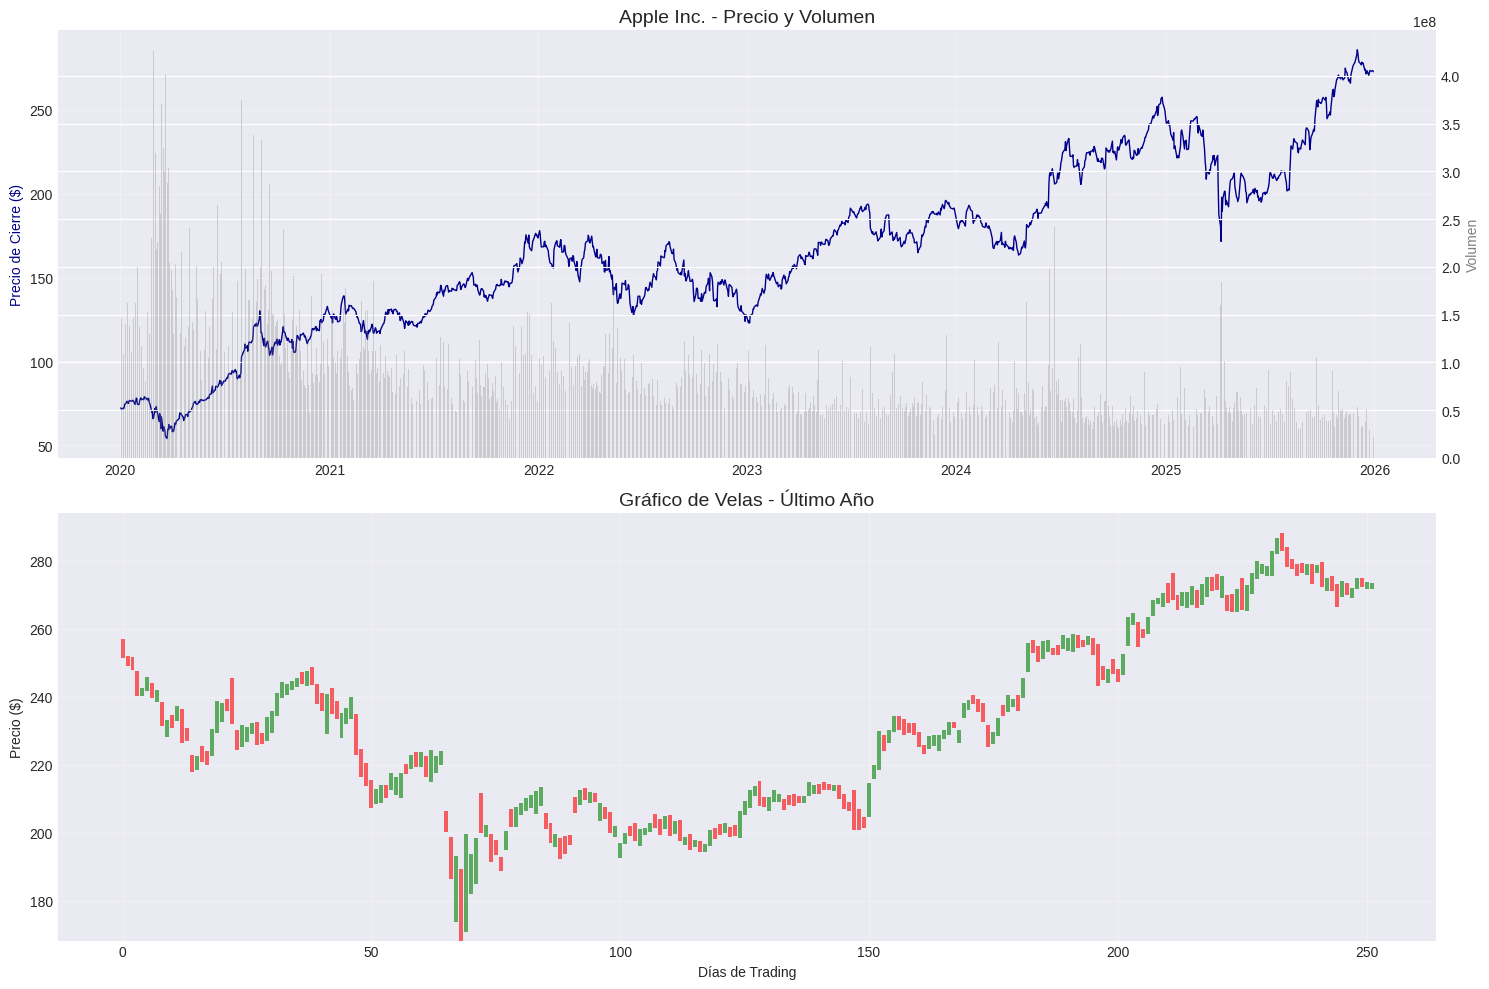

In [ ]:
# Información básica
print("\n📊 Información del Dataset:")
print(
    f"Período: {df_stock_data.index[0].strftime('%Y-%m-%d')} a {df_stock_data.index[-1].strftime('%Y-%m-%d')}"
)
print(f"Total de días de trading: {len(df_stock_data)}")
print(
    f"Años de datos: {(df_stock_data.index[-1] - df_stock_data.index[0]).days / 365:.1f}"
)

# Visualización inicial
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Precio y volumen
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df_stock_data.index, df_stock_data["Close"], color="darkblue", linewidth=1)
ax2.bar(df_stock_data.index, df_stock_data["Volume"], alpha=0.3, color="gray")
ax1.set_ylabel("Precio de Cierre ($)", color="darkblue")
ax2.set_ylabel("Volumen", color="gray")
ax1.set_title("Apple Inc. - Precio y Volumen", fontsize=14)
ax1.grid(True, alpha=0.3)

# OHLC con velas japonesas
ax3 = axes[1]
# Simplificamos mostrando solo el último año para mejor visualización
last_year_data = df_stock_data.iloc[-252:]
colors = [
    "g" if close >= open_ else "r"
    for close, open_ in zip(last_year_data["Close"], last_year_data["Open"])
]
ax3.bar(
    range(len(last_year_data)),
    last_year_data["High"] - last_year_data["Low"],
    bottom=last_year_data["Low"],
    color=colors,
    alpha=0.6,
)
ax3.set_title("Gráfico de Velas - Último Año", fontsize=14)
ax3.set_ylabel("Precio ($)")
ax3.set_xlabel("Días de Trading")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.2 Cálculo de indicadores técnicos

In [ ]:
def calculate_rsi(data, window=14):
    """
    Calculates the Relative Strength Index (RSI) for the given financial data.

    The RSI is a momentum indicator that measures the speed and change of price movements.

    Args:
        data (pd.DataFrame): DataFrame containing 'Close' prices.
        window (int, optional): The look-back period for RSI calculation. Defaults to 14.

    Returns:
        pd.Series: A Series containing the RSI values.
    """
    # Calcular los cambios diarios de precio
    delta = data["Close"].diff()

    # Separar ganancias (gains) y pérdidas (losses)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    # Calcular el promedio de ganancias y pérdidas durante la ventana
    avg_gain = gain.rolling(window=window, min_periods=1).mean()
    avg_loss = loss.rolling(window=window, min_periods=1).mean()

    # Calcular Relative Strength (RS)
    rs = avg_gain / avg_loss

    # Calcular Relative Strength Index (RSI)
    rsi = 100 - (100 / (1 + rs))
    return rsi


# Calcular el RSI y añadirlo al DataFrame df_stock_data
df_stock_data["RSI"] = calculate_rsi(df_stock_data)
# Calcula la media móvil exponencial (EMA)
ema_window = 20  # Por ejemplo, una EMA de 20 períodos
df_stock_data["EMA"] = df_stock_data["Close"].ewm(span=ema_window, adjust=False).mean()
# Calcula la Convergencia/Divergencia de la Media Móvil (MACD)
# Definir los períodos para las EMAs del MACD (comúnmente 12 y 26)
short_ema_window = 12
long_ema_window = 26
signal_line_window = 9
# Calcular la EMA corta
df_stock_data["EMA_Short"] = (
    df_stock_data["Close"].ewm(span=short_ema_window, adjust=False).mean()
)
# Calcular la EMA larga
df_stock_data["EMA_Long"] = (
    df_stock_data["Close"].ewm(span=long_ema_window, adjust=False).mean()
)
# Calcular la línea MACD
df_stock_data["MACD"] = df_stock_data["EMA_Short"] - df_stock_data["EMA_Long"]
# Calcular la línea de señal (EMA de la línea MACD)
df_stock_data["Signal_Line"] = (
    df_stock_data["MACD"].ewm(span=signal_line_window, adjust=False).mean()
)
# Calcular el histograma MACD
df_stock_data["MACD_Histogram"] = df_stock_data["MACD"] - df_stock_data["Signal_Line"]

# PARA SACAR EL PANTALLAZO, MOSTRAMOS SOLO LAS COLUMNAS RELATIVAS A MÉTRICAS TECNICAS
df_stock_data[
    ["RSI", "EMA", "EMA_Short", "EMA_Long", "MACD", "Signal_Line", "MACD_Histogram"]
]

Price,RSI,EMA,EMA_Short,EMA_Long,MACD,Signal_Line,MACD_Histogram
Date,,,,,,,
2020-01-02,NaN,72.333885,72.333885,72.333885,0.000000,0.000000,0.000000
2020-01-03,0.000000,72.266909,72.225693,72.281793,-0.056099,-0.011220,-0.044880
2020-01-06,44.800824,72.260671,72.221957,72.275838,-0.053881,-0.019752,-0.034129
2020-01-07,35.372940,72.222688,72.166556,72.245172,-0.078617,-0.031525,-0.047092
2020-01-08,62.347422,72.298415,72.297520,72.302406,-0.004886,-0.026197,0.021311
...,...,...,...,...,...,...,...
2025-12-23,24.291311,274.038325,273.809069,273.439037,0.370032,1.727568,-1.357535
2025-12-24,33.540327,273.968220,273.731092,273.428902,0.302190,1.442492,-1.140302
2025-12-26,36.148319,273.865818,273.602155,273.389206,0.212949,1.196584,-0.983634


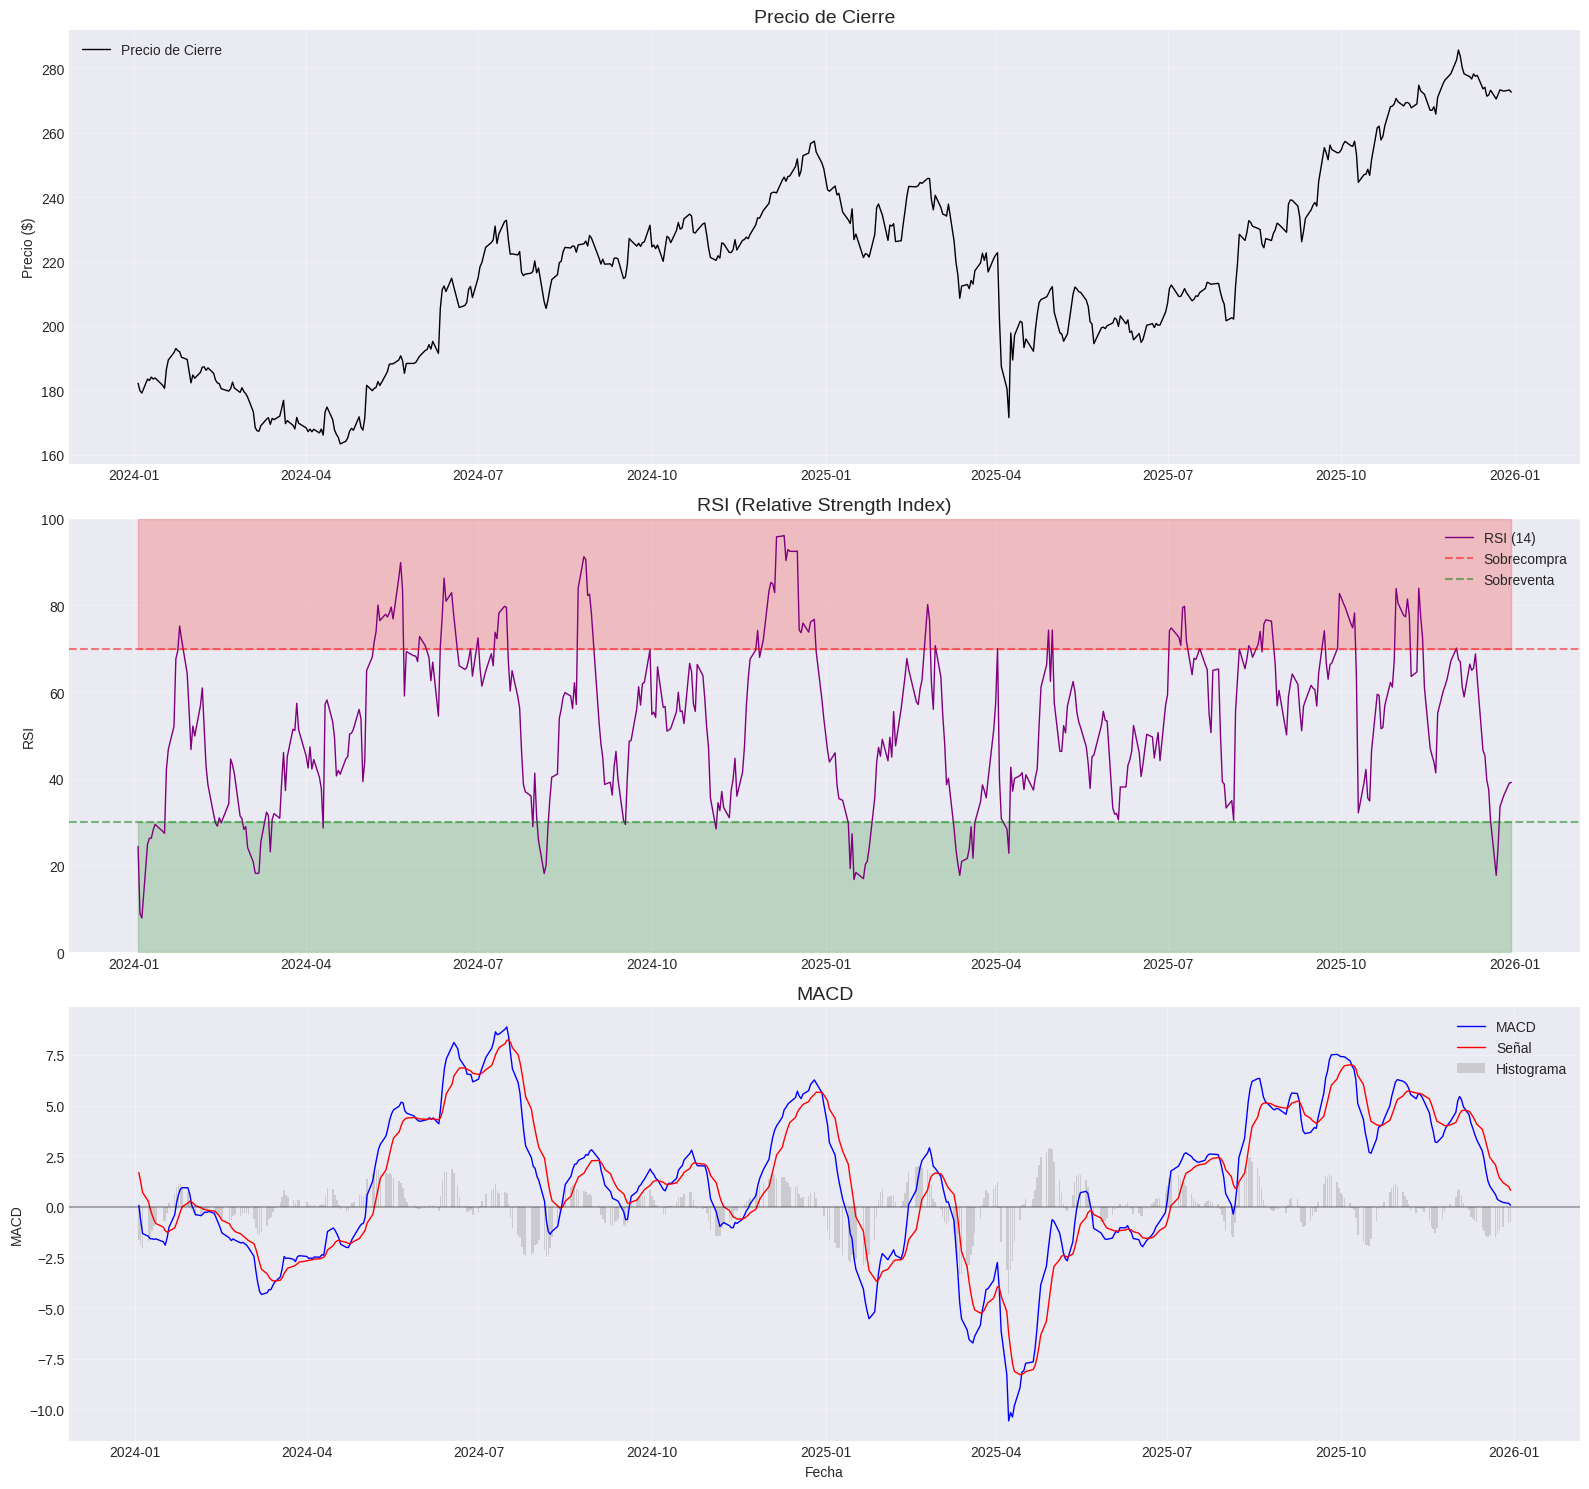


📊 Resumen de Indicadores Técnicos Actuales:
Indicador Valor Actual Interpretación
      RSI        39.13        Neutral
     MACD         0.08        Bajista


In [ ]:
# Celda 6: Visualización de indicadores técnicos
fig, axes = plt.subplots(
    3, 1, figsize=(16, 15)
)  # Changed from 5 to 3 subplots, adjusted figsize

# Seleccionar últimos 500 días para mejor visualización
plot_data = df_stock_data.iloc[-500:]  # Changed from apple_technical to stock_data

# 1. Precio de Cierre
ax1 = axes[0]
ax1.plot(
    plot_data.index,
    plot_data["Close"],
    label="Precio de Cierre",
    color="black",
    linewidth=1,
)
ax1.set_title("Precio de Cierre", fontsize=14)
ax1.set_ylabel("Precio ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. RSI
ax2 = axes[1]
ax2.plot(
    plot_data.index, plot_data["RSI"], label="RSI (14)", color="purple", linewidth=1
)
ax2.axhline(y=70, color="red", linestyle="--", alpha=0.5, label="Sobrecompra")
ax2.axhline(y=30, color="green", linestyle="--", alpha=0.5, label="Sobreventa")
ax2.fill_between(plot_data.index, 70, 100, alpha=0.2, color="red")
ax2.fill_between(plot_data.index, 0, 30, alpha=0.2, color="green")
ax2.set_title("RSI (Relative Strength Index)", fontsize=14)
ax2.set_ylabel("RSI")
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. MACD
ax3 = axes[2]
ax3.plot(plot_data.index, plot_data["MACD"], label="MACD", color="blue", linewidth=1)
ax3.plot(
    plot_data.index,
    plot_data["Signal_Line"],
    label="Señal",  # Changed MACD_Signal to Signal_Line
    color="red",
    linewidth=1,
)
ax3.bar(
    plot_data.index,
    plot_data["MACD_Histogram"],
    label="Histograma",
    color="gray",
    alpha=0.3,
)
ax3.axhline(y=0, color="black", linestyle="-", alpha=0.3)
ax3.set_title("MACD", fontsize=14)
ax3.set_ylabel("MACD")
ax3.set_xlabel("Fecha")  # Added xlabel for the last plot
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen de indicadores actuales
current_indicators = pd.DataFrame(
    {
        "Indicador": ["RSI", "MACD"],  # Removed unavailable indicators
        "Valor Actual": [
            f"{df_stock_data['RSI'].iloc[-1]:.2f}",  # Changed apple_technical to stock_data
            f"{df_stock_data['MACD'].iloc[-1]:.2f}",  # Changed apple_technical to stock_data
        ],
        "Interpretación": [
            "Sobrecompra"
            if df_stock_data["RSI"].iloc[-1] > 70
            # Changed apple_technical to stock_data
            else "Sobreventa"
            if df_stock_data["RSI"].iloc[-1] < 30
            else "Neutral",
            "Alcista"
            if df_stock_data["MACD"].iloc[-1] > df_stock_data["Signal_Line"].iloc[-1]
            else "Bajista",  # Changed MACD_Signal to Signal_Line, and apple_technical to stock_data
        ],
    }
)

print("\n📊 Resumen de Indicadores Técnicos Actuales:")
print(current_indicators.to_string(index=False))

## 3. Recolección de Datos Fundamentales

In [ ]:
import yfinance as yf

# Crear un objeto Ticker para Apple
apple_ticker = yf.Ticker(ticker)

# Obtener información fundamental de la compañía
company_info = apple_ticker.info

print(f"--- Datos fundamentales clave para {ticker} ---")

# 1. Rentabilidad (Profitability)
print("\n### Rentabilidad:")
print(
    f"ROE (Return on Equity): {company_info.get('returnOnEquity', 'N/A'):.2f}"
    if company_info.get("returnOnEquity") is not None
    else "ROE (Return on Equity): N/A"
)
print(
    f"ROA (Return on Assets): {company_info.get('returnOnAssets', 'N/A'):.2f}"
    if company_info.get("returnOnAssets") is not None
    else "ROA (Return on Assets): N/A"
)
print(
    f"Margen de Beneficio Neto (Profit Margins): {company_info.get('profitMargins', 'N/A'):.2%}"
    if company_info.get("profitMargins") is not None
    else "Margen de Beneficio Neto (Profit Margins): N/A"
)

# 2. Liquidez (Liquidity)
print("\n### Liquidez:")
print(
    f"Ratio Corriente (Current Ratio): {company_info.get('currentRatio', 'N/A'):.2f}"
    if company_info.get("currentRatio") is not None
    else "Ratio Corriente (Current Ratio): N/A"
)
print(
    f"Ratio Rápido (Quick Ratio): {company_info.get('quickRatio', 'N/A'):.2f}"
    if company_info.get("quickRatio") is not None
    else "Ratio Rápido (Quick Ratio): N/A"
)
print(
    f"Rotación de Inventarios (Inventory Turnover): {company_info.get('inventoryTurnover', 'N/A'):.2f}"
    if company_info.get("inventoryTurnover") is not None
    else "Rotación de Inventarios (Inventory Turnover): N/A"
)

# 3. Solvencia (Solvency)
print("\n### Solvencia:")
print(
    f"Ratio Deuda/Capital (Debt/Equity): {company_info.get('debtToEquity', 'N/A'):.2f}"
    if company_info.get("debtToEquity") is not None
    else "Ratio Deuda/Capital (Debt/Equity): N/A"
)

# Calculate Debt/Assets if totalDebt and totalAssets are available
total_debt = company_info.get("totalDebt")
total_assets = company_info.get("totalAssets")
if total_debt is not None and total_assets is not None and total_assets != 0:
    debt_to_assets = total_debt / total_assets
    print(f"Ratio Deuda/Activos (Debt/Assets): {debt_to_assets:.2f}")
else:
    print("Ratio Deuda/Activos (Debt/Assets): N/A (datos no disponibles)")

# Interest Coverage often requires more detailed financials not always in .info
print(
    "Cobertura de Intereses (Interest Coverage): N/A (requiere datos financieros más detallados)"
)

# 4. Valoración (Valuation)
print("\n### Valoración:")
print(
    f"PER (Trailing Price/Earnings Ratio): {company_info.get('trailingPE', 'N/A'):.2f}"
    if company_info.get("trailingPE") is not None
    else "PER (Trailing Price/Earnings Ratio): N/A"
)
print(
    f"PER (Forward Price/Earnings Ratio): {company_info.get('forwardPE', 'N/A'):.2f}"
    if company_info.get("forwardPE") is not None
    else "PER (Forward Price/Earnings Ratio): N/A"
)
print(
    f"P/B (Price-to-Book Ratio): {company_info.get('priceToBook', 'N/A'):.2f}"
    if company_info.get("priceToBook") is not None
    else "P/B (Price-to-Book Ratio): N/A"
)
print(
    f"EV/EBITDA: {company_info.get('enterpriseToEbitda', 'N/A'):.2f}"
    if company_info.get("enterpriseToEbitda") is not None
    else "EV/EBITDA: N/A"
)

--- Datos fundamentales clave para AAPL ---

### Rentabilidad:
ROE (Return on Equity): 1.41
ROA (Return on Assets): 0.26
Margen de Beneficio Neto (Profit Margins): 27.15%

### Liquidez:
Ratio Corriente (Current Ratio): 1.07
Ratio Rápido (Quick Ratio): 0.91
Rotación de Inventarios (Inventory Turnover): N/A

### Solvencia:
Ratio Deuda/Capital (Debt/Equity): 79.55
Ratio Deuda/Activos (Debt/Assets): N/A (datos no disponibles)
Cobertura de Intereses (Interest Coverage): N/A (requiere datos financieros más detallados)

### Valoración:
PER (Trailing Price/Earnings Ratio): 37.64
PER (Forward Price/Earnings Ratio): 32.40
P/B (Price-to-Book Ratio): 42.88
EV/EBITDA: 28.32


## 4. Unificación de Datos en un DataFrame Único

In [ ]:
display(df_stock_data.head(2))
display(df_vix_data.head(2))
display(df_sentimiento.head(2))

Price,Close,High,Low,Open,Volume,RSI,EMA,EMA_Short,EMA_Long,MACD,Signal_Line,MACD_Histogram
Date,,,,,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400,NaN,72.333885,72.333885,72.333885,0.000000,0.00000,0.00000
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,0.0,72.266909,72.225693,72.281793,-0.056099,-0.01122,-0.04488


Price,VIX,VIX_Category
Date,,
2020-01-02,12.47,Bajo
2020-01-03,14.02,Bajo


,volumen_noticias,sentimiento_promedio,puntuacion_positiva,puntuacion_negativa,polaridad_promedio,volatilidad_sentimiento,uso_primera_persona
Date,,,,,,,
2020-01-01,111,-1.022,2.360,3.381,5.741,3.125,22.523
2020-01-02,319,0.109,2.381,2.272,4.653,2.470,22.716


In [ ]:
# Unificar todos los datos
df_master = pd.concat(
    [
        df_stock_data,
        df_sentimiento[["sentimiento_promedio", "volatilidad_sentimiento"]],
        df_vix_data[["VIX"]],
    ],
    axis=1,
)

# Eliminar filas que no tienen datos de cotización (donde 'Close' es NaN)
df_master = df_master.dropna(subset=["Close"])

print("DataFrame unificado 'df_master' creado. Primeras 5 filas:")
display(df_master.head())
print(f"Dimensiones de df_master: {df_master.shape}")

DataFrame unificado 'df_master' creado. Primeras 5 filas:


,Close,High,Low,Open,Volume,RSI,EMA,EMA_Short,EMA_Long,MACD,Signal_Line,MACD_Histogram,sentimiento_promedio,volatilidad_sentimiento,VIX
Date,,,,,,,,,,,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400.0,NaN,72.333885,72.333885,72.333885,0.000000,0.000000,0.000000,0.109,2.470,12.47
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800.0,0.000000,72.266909,72.225693,72.281793,-0.056099,-0.011220,-0.044880,-0.434,2.696,14.02
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200.0,44.800824,72.260671,72.221957,72.275838,-0.053881,-0.019752,-0.034129,0.418,3.478,13.85
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000.0,35.372940,72.222688,72.166556,72.245172,-0.078617,-0.031525,-0.047092,0.330,2.913,13.79
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200.0,62.347422,72.298415,72.297520,72.302406,-0.004886,-0.026197,0.021311,0.523,2.572,13.45


Dimensiones de df_master: (1507, 15)


In [ ]:
# Añadir características temporales
df_master["day_of_week"] = df_master.index.dayofweek
df_master["month"] = df_master.index.month
df_master["quarter"] = df_master.index.quarter
df_master["year"] = df_master.index.year
df_master["day_of_month"] = df_master.index.day
df_master["week_of_year"] = df_master.index.isocalendar().week

# Añadir características cíclicas
df_master["month_sin"] = np.sin(2 * np.pi * df_master["month"] / 12)
df_master["month_cos"] = np.cos(2 * np.pi * df_master["month"] / 12)
df_master["day_sin"] = np.sin(2 * np.pi * df_master["day_of_week"] / 7)
df_master["day_cos"] = np.cos(2 * np.pi * df_master["day_of_week"] / 7)

# Crear interacciones entre variables clave
# 'Return_5d' no está en el DataFrame, por lo que se eliminará por ahora.
# Necesitaríamos recalcular los retornos si se quieren usar.
df_master["sentiment_volume_interaction"] = (
    df_master["sentimiento_promedio"] * df_master["Volume"]
)
df_master["vix_rsi_interaction"] = df_master["VIX"] * df_master["RSI"] / 100

In [ ]:
# Limpiar datos
print("\n🧹 Limpieza de datos:")
print(f"Filas antes de limpieza: {len(df_master)}")
print(f"Columnas totales: {len(df_master.columns)}")

# Eliminar columnas con más del 50% de valores faltantes
missing_threshold = 0.5
missing_pct = df_master.isnull().sum() / len(df_master)
cols_to_drop = missing_pct[missing_pct > missing_threshold].index
df_master = df_master.drop(columns=cols_to_drop)
print(f"Columnas eliminadas por exceso de NaN: {len(cols_to_drop)}")

# Eliminar filas con valores faltantes
df_master = df_master.dropna()
print(f"Filas después de limpieza: {len(df_master)}")


🧹 Limpieza de datos:
Filas antes de limpieza: 1507
Columnas totales: 27
Columnas eliminadas por exceso de NaN: 0
Filas después de limpieza: 1495


## EVIDENCIA

Se muestra una tabla consolidada donde cada fila represente una fecha y las columnas incluyan variables de sentimiento, técnicas y fundamentales.

In [ ]:
display(df_master.head(4))
df_master.info()

,Close,High,Low,Open,Volume,RSI,EMA,EMA_Short,EMA_Long,MACD,...,quarter,year,day_of_month,week_of_year,month_sin,month_cos,day_sin,day_cos,sentiment_volume_interaction,vix_rsi_interaction
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800.0,0.000000,72.266909,72.225693,72.281793,-0.056099,...,1,2020,3,1,0.5,0.866025,-0.433884,-0.900969,-63504095.2,0.000000
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200.0,44.800824,72.260671,72.221957,72.275838,-0.053881,...,1,2020,6,2,0.5,0.866025,0.000000,1.000000,49485849.6,6.204914
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000.0,35.372940,72.222688,72.166556,72.245172,-0.078617,...,1,2020,7,2,0.5,0.866025,0.781831,0.623490,35927760.0,4.877928
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200.0,62.347422,72.298415,72.297520,72.302406,-0.004886,...,1,2020,8,2,0.5,0.866025,0.974928,-0.222521,69077421.6,8.385728


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1495 entries, 2020-01-03 to 2025-12-30
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Close                         1495 non-null   float64
 1   High                          1495 non-null   float64
 2   Low                           1495 non-null   float64
 3   Open                          1495 non-null   float64
 4   Volume                        1495 non-null   float64
 5   RSI                           1495 non-null   float64
 6   EMA                           1495 non-null   float64
 7   EMA_Short                     1495 non-null   float64
 8   EMA_Long                      1495 non-null   float64
 9   MACD                          1495 non-null   float64
 10  Signal_Line                   1495 non-null   float64
 11  MACD_Histogram                1495 non-null   float64
 12  sentimiento_promedio          1495 non-null 

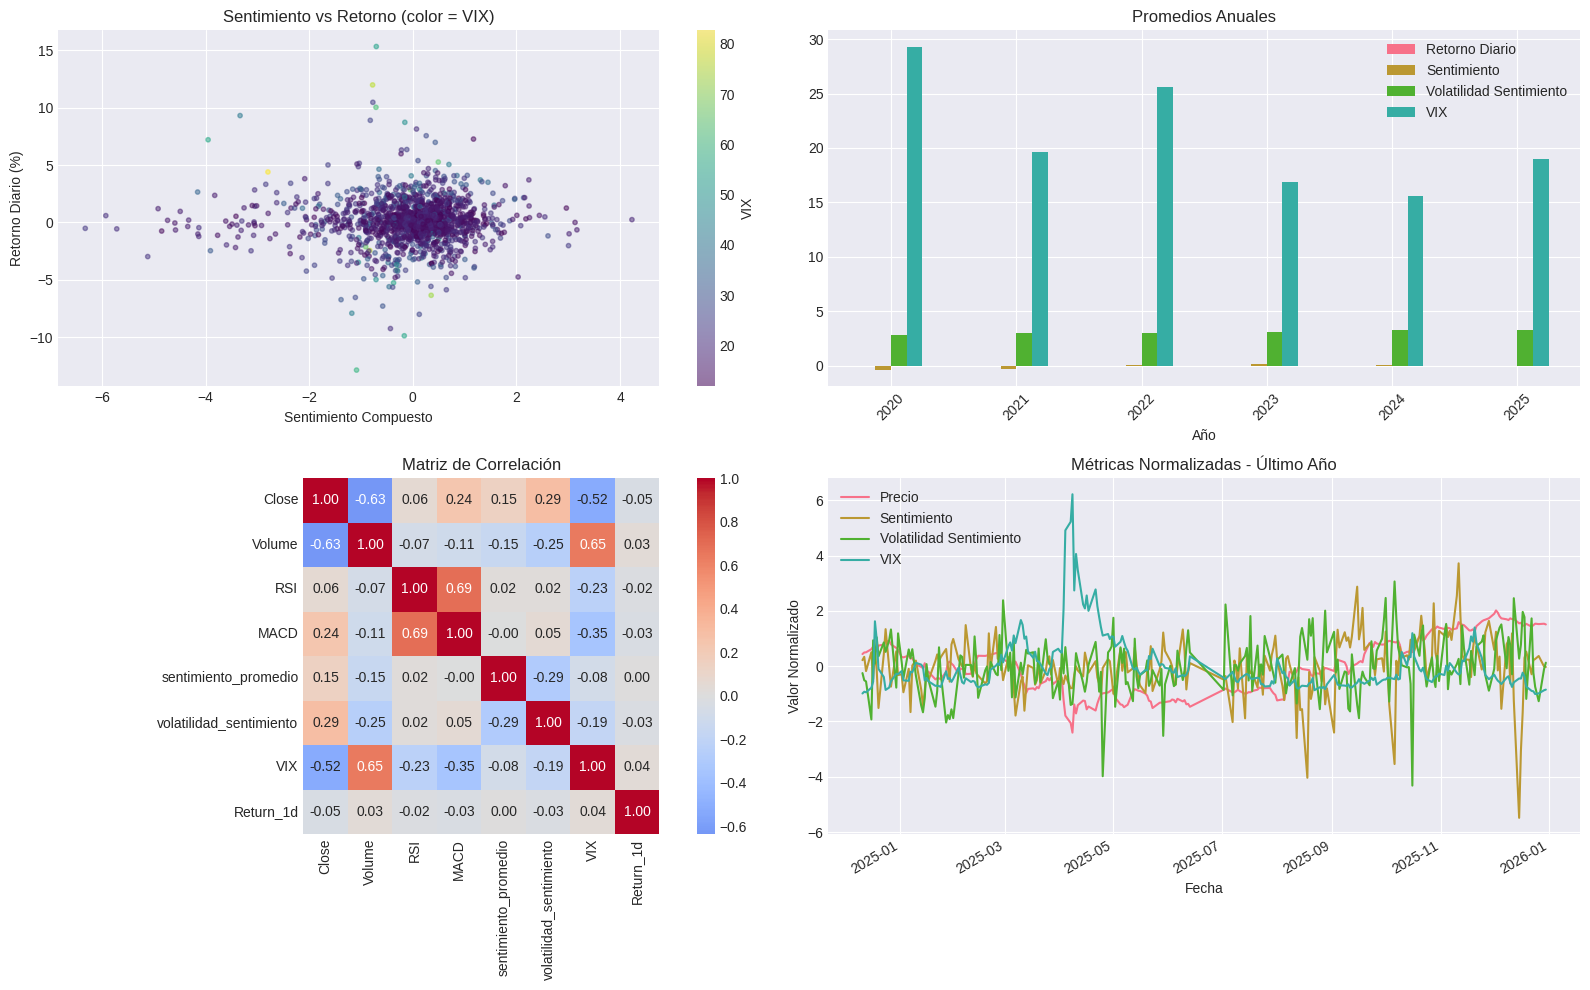


✅ DataFrame maestro creado exitosamente!
Dimensiones finales: (1495, 28)

Primeras columnas disponibles:
  1. Close
  2. High
  3. Low
  4. Open
  5. Volume
  6. RSI
  7. EMA
  8. EMA_Short
  9. EMA_Long
  10. MACD
  11. Signal_Line
  12. MACD_Histogram
  13. sentimiento_promedio
  14. volatilidad_sentimiento
  15. VIX
  16. day_of_week
  17. month
  18. quarter
  19. year
  20. day_of_month
  ... y 8 columnas más


In [ ]:
# Visualización del dataset unificado
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Recalcular Return_1d si no existe para la visualización
if "Return_1d" not in df_master.columns:
    df_master["Return_1d"] = (
        df_master["Close"].pct_change().shift(-1)
    )  # calculate 1-day return

# 1. Correlación entre sentimiento y precio
ax1 = axes[0, 0]
scatter = ax1.scatter(
    df_master["sentimiento_promedio"],
    df_master["Return_1d"] * 100,
    c=df_master["VIX"],
    cmap="viridis",
    alpha=0.5,
    s=10,
)
ax1.set_xlabel("Sentimiento Compuesto")
ax1.set_ylabel("Retorno Diario (%)")
ax1.set_title("Sentimiento vs Retorno (color = VIX)")
plt.colorbar(scatter, ax=ax1, label="VIX")

# 2. Distribución de características por año
ax2 = axes[0, 1]
yearly_stats = df_master.groupby("year")[
    ["Return_1d", "sentimiento_promedio", "volatilidad_sentimiento", "VIX"]
].mean()
yearly_stats.plot(kind="bar", ax=ax2)
ax2.set_title("Promedios Anuales")
ax2.set_xlabel("Año")
ax2.legend(["Retorno Diario", "Sentimiento", "Volatilidad Sentimiento", "VIX"])
ax2.tick_params(axis="x", rotation=45)

# 3. Heatmap de correlaciones top
ax3 = axes[1, 0]
# Las características BB_Upper, BB_Lower, Stoch_K, Williams_R no están en stock_data
key_features = [
    "Close",
    "Volume",
    "RSI",
    "MACD",
    "sentimiento_promedio",
    "volatilidad_sentimiento",
    "VIX",
    "Return_1d",
]  # Removed 'ROE', as fundamental_metrics is not used for now
available_features = [f for f in key_features if f in df_master.columns]
corr_matrix = df_master[available_features].corr()
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax3, fmt=".2f", square=True
)
ax3.set_title("Matriz de Correlación")

# 4. Series temporales de métricas clave
ax4 = axes[1, 1]
normalized_data = df_master[
    ["Close", "sentimiento_promedio", "volatilidad_sentimiento", "VIX"]
].iloc[-252:]
normalized_data = (normalized_data - normalized_data.mean()) / normalized_data.std()
normalized_data.plot(ax=ax4)
ax4.set_title("Métricas Normalizadas - Último Año")
ax4.set_xlabel("Fecha")
ax4.set_ylabel("Valor Normalizado")
ax4.legend(["Precio", "Sentimiento", "Volatilidad Sentimiento", "VIX"])

plt.tight_layout()
plt.show()

print("\n✅ DataFrame maestro creado exitosamente!")
print(f"Dimensiones finales: {df_master.shape}")
print("\nPrimeras columnas disponibles:")
for i, col in enumerate(df_master.columns[:20]):
    print(f"  {i + 1}. {col}")
print(f"  ... y {len(df_master.columns) - 20} columnas más")

## 5. Desarrollo del Modelo Predictivo

In [ ]:
# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

🎯 Preparando datos para el modelo predictivo...

📊 Características disponibles: 27
Forma de X: (1494, 27)
Forma de y: (1494,)
Distribución de clases: {1: 793, 0: 701}
Balance de clases: 53.08% positivas


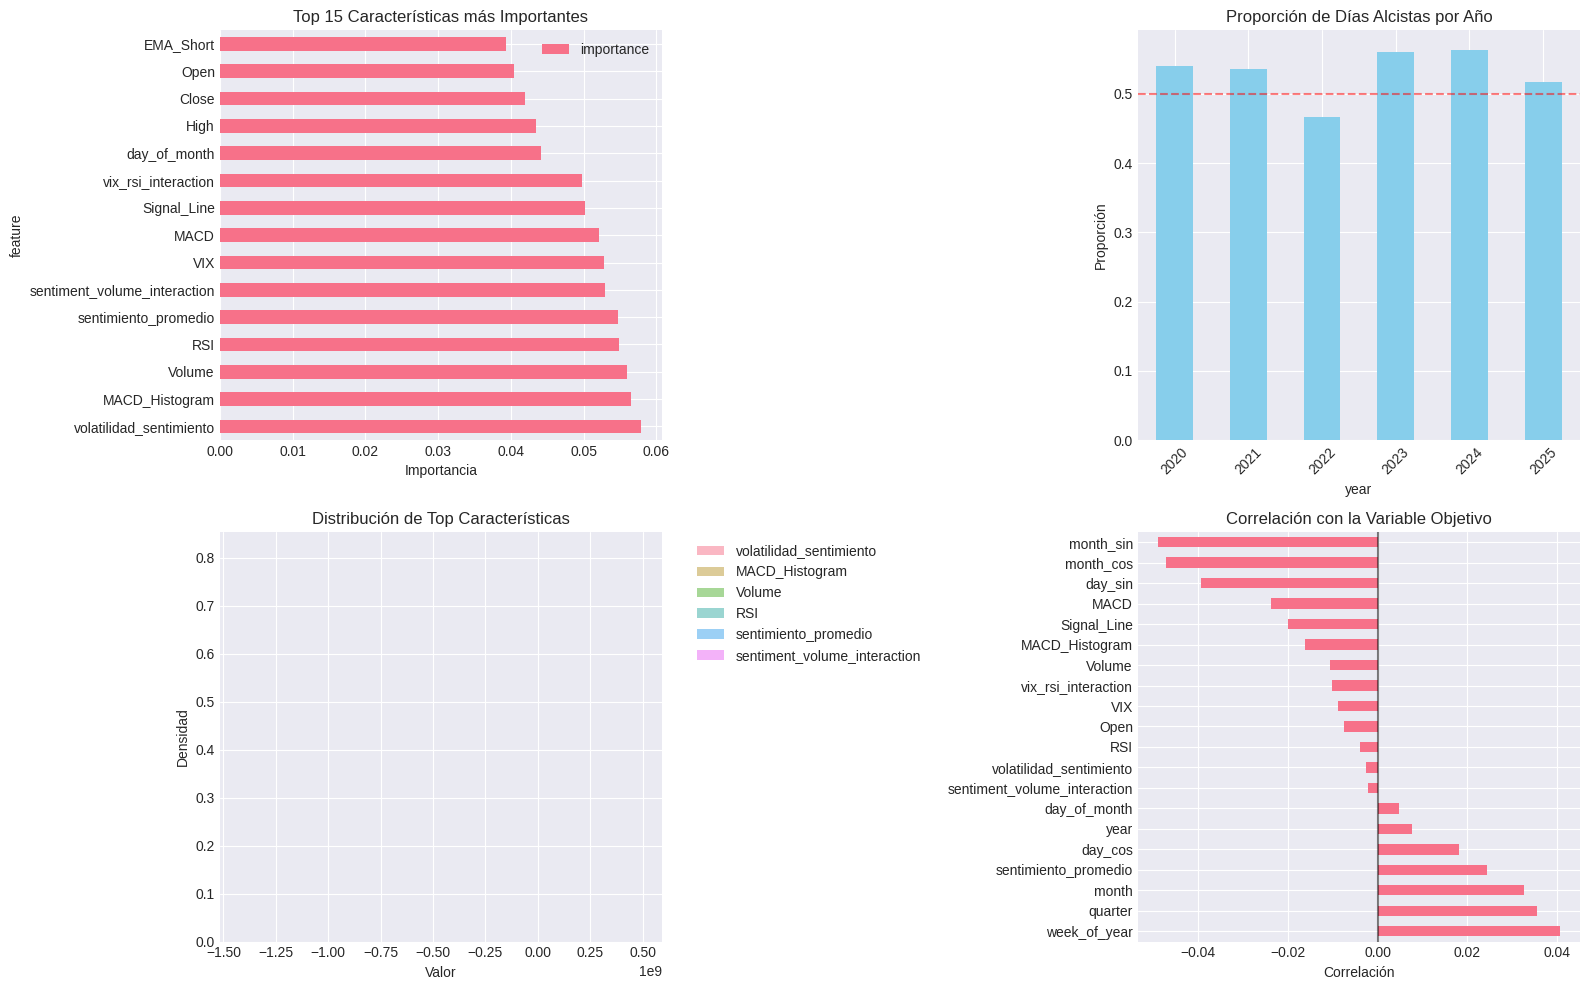

In [ ]:
print("🎯 Preparando datos para el modelo predictivo...")

# Crear variable objetivo
df_master["target"] = (df_master["Close"].shift(-1) > df_master["Close"]).astype(int)

# Seleccionar características relevantes (actualizado para reflejar las columnas disponibles)
feature_columns = [
    # Técnicos
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "RSI",
    "EMA",
    "EMA_Short",
    "EMA_Long",
    "MACD",
    "Signal_Line",
    "MACD_Histogram",
    # Sentimiento (usando los nombres de df_sentimiento)
    "sentimiento_promedio",
    "volatilidad_sentimiento",
    # Mercado
    "VIX",
    # Temporales
    "day_of_week",
    "month",
    "quarter",
    "year",
    "day_of_month",
    "week_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    # Interacciones
    "sentiment_volume_interaction",
    "vix_rsi_interaction",
]

# Filtrar solo las columnas disponibles
# Aunque la lista feature_columns ya es precisa, mantenemos esta línea para robustez
available_features = [col for col in feature_columns if col in df_master.columns]
print(f"\n📊 Características disponibles: {len(available_features)}")

# Preparar X e y
X = df_master[available_features].dropna()
y = df_master.loc[X.index, "target"]

# Eliminar la última fila (no tiene target)
X = X[:-1]
y = y[:-1]

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Distribución de clases: {y.value_counts().to_dict()}")
print(f"Balance de clases: {y.mean():.2%} positivas")

# Análisis de características
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Importancia de características usando Random Forest
ax1 = axes[0, 0]
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)
feature_importance = (
    pd.DataFrame(
        {
            "feature": X.columns,  # Usar X.columns directamente ya que available_features son las de X
            "importance": rf_temp.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(15)
)

feature_importance.plot(x="feature", y="importance", kind="barh", ax=ax1)
ax1.set_title("Top 15 Características más Importantes")
ax1.set_xlabel("Importancia")

# 2. Distribución de la variable objetivo por período
ax2 = axes[0, 1]
target_by_year = df_master.groupby("year")["target"].mean()
target_by_year.plot(kind="bar", ax=ax2, color="skyblue")
ax2.set_title("Proporción de Días Alcistas por Año")
ax2.set_ylabel("Proporción")
ax2.axhline(y=0.5, color="red", linestyle="--", alpha=0.5)
ax2.tick_params(axis="x", rotation=45)

# 3. Análisis de características por clase
ax3 = axes[1, 0]
top_features = feature_importance.head(6)["feature"].values
for i, feature in enumerate(top_features):
    if feature in X.columns:
        X[feature].hist(bins=30, alpha=0.5, ax=ax3, label=f"{feature}", density=True)
ax3.set_title("Distribución de Top Características")
ax3.set_xlabel("Valor")
ax3.set_ylabel("Densidad")
ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# 4. Correlación con el target
ax4 = axes[1, 1]
target_corr = X.corrwith(y).sort_values(ascending=False)
top_corr_features = pd.concat([target_corr.head(10), target_corr.tail(10)])
top_corr_features.plot(kind="barh", ax=ax4)
ax4.set_title("Correlación con la Variable Objetivo")
ax4.set_xlabel("Correlación")
ax4.axvline(x=0, color="black", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.show()

🤖 Implementando modelos de Machine Learning...

📊 División de datos:
Entrenamiento: 1195 muestras (80.0%)者に
Prueba: 299 muestras (20.0%)者に
Balance en train: 52.97% positivas
Balance en test: 53.51% positivas

🔄 Después de SMOTE:
Muestras de entrenamiento: 1266
Balance: 50.00% positivas

1️⃣ Entrenando Random Forest...
2️⃣ Entrenando XGBoost...
3️⃣ Entrenando LSTM mejorado...
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


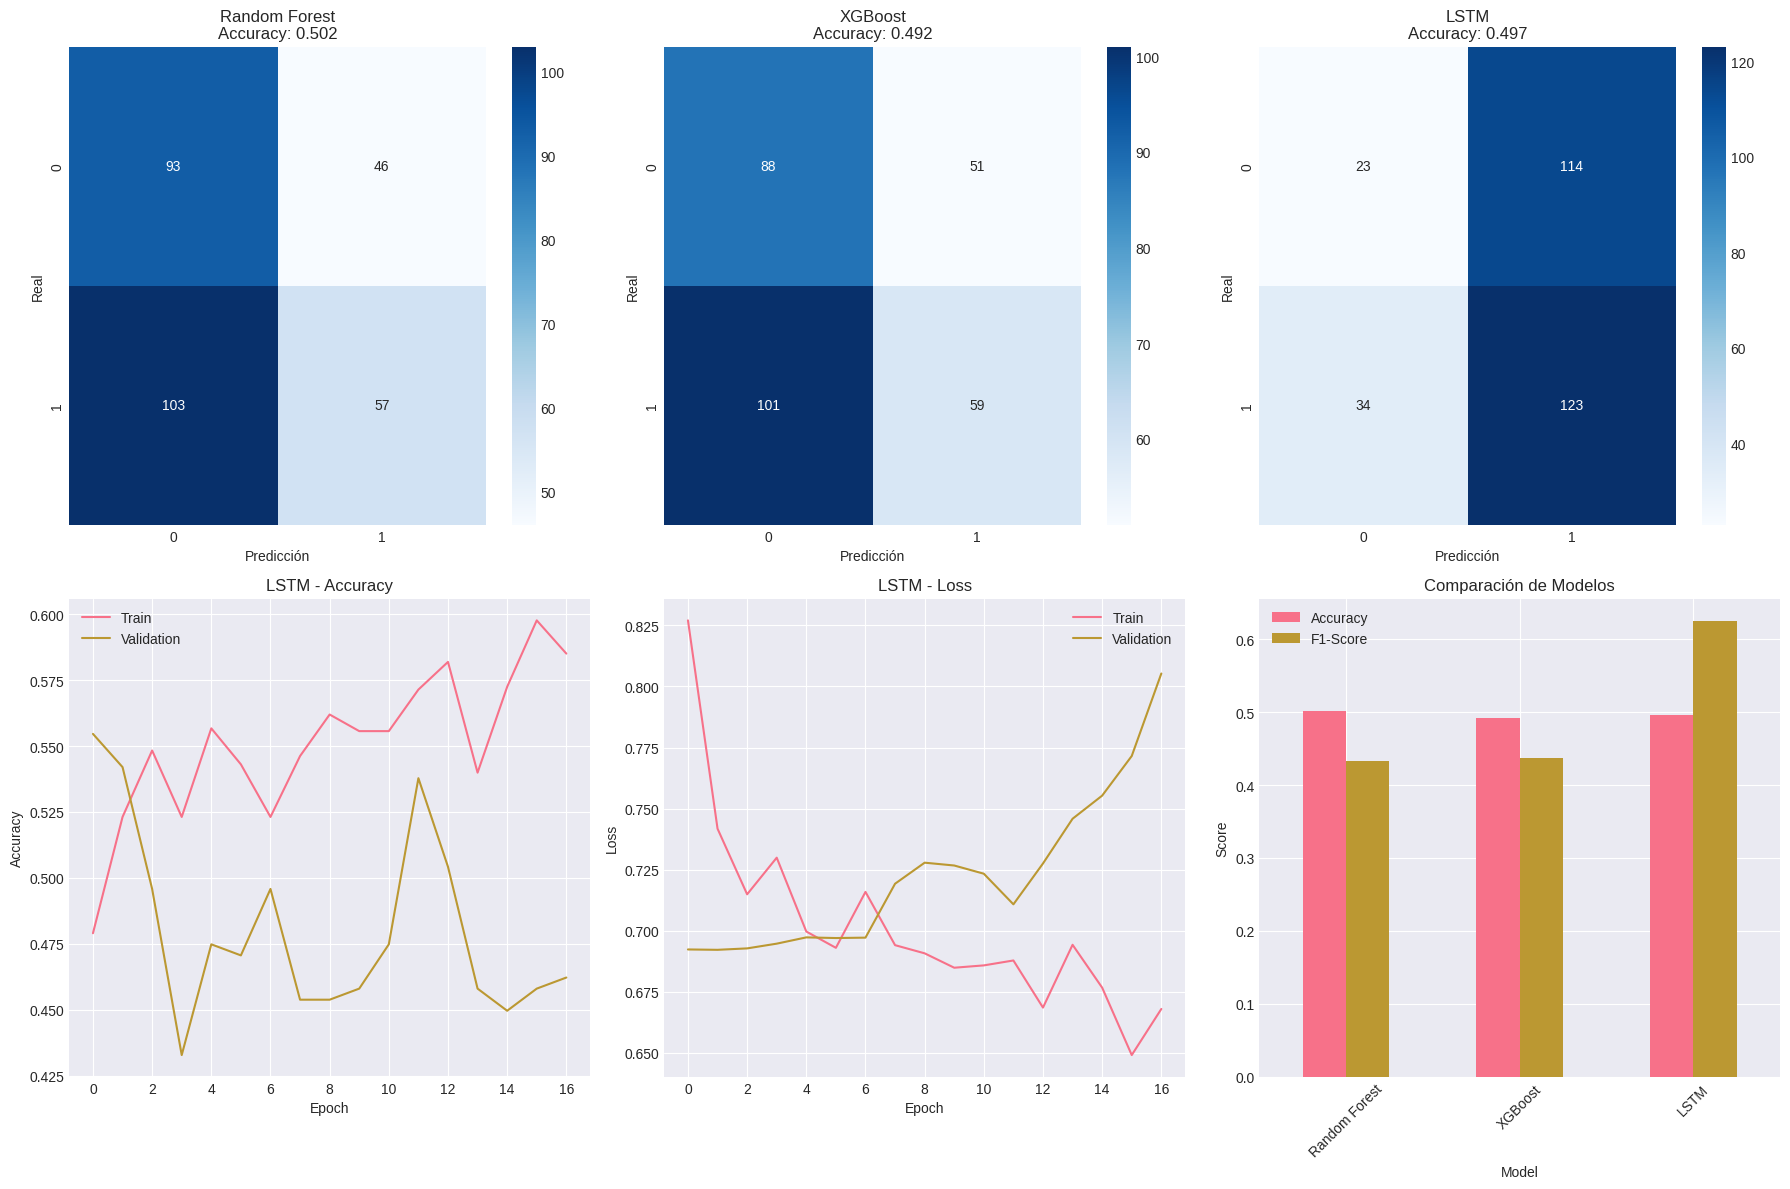


📊 RESULTADOS DETALLADOS:

Random Forest:
  Accuracy: 0.5017
  F1-Score: 0.4335

XGBoost:
  Accuracy: 0.4916
  F1-Score: 0.4370

LSTM:
  Accuracy: 0.4966
  F1-Score: 0.6244


In [ ]:
import xgboost as xgb

# Celda 10: Implementación de múltiples modelos con validación temporal
# This cell was modified to ensure X and y are defined before execution.
print("🤖 Implementando modelos de Machine Learning...")

# División temporal de datos (80% train, 20% test)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("\n📊 División de datos:")
print(
    f"Entrenamiento: {len(X_train)} muestras ({len(X_train) / len(X) * 100:.1f}%)者に"
)
print(f"Prueba: {len(X_test)} muestras ({len(X_test) / len(X) * 100:.1f}%)者に")
print(f"Balance en train: {y_train.mean():.2%} positivas")
print(f"Balance en test: {y_test.mean():.2%} positivas")

# Normalización de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Aplicar SMOTE para balancear clases
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\n🔄 Después de SMOTE:")
print(f"Muestras de entrenamiento: {len(X_train_balanced)}")
print(f"Balance: {y_train_balanced.mean():.2%} positivas")

# Diccionario para almacenar resultados
results = {}

# 1. Random Forest
print("\n1️⃣ Entrenando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

results["Random Forest"] = {
    "model": rf_model,
    "predictions": rf_pred,
    "probabilities": rf_pred_proba,
    "accuracy": accuracy_score(y_test, rf_pred),
    "f1_score": f1_score(y_test, rf_pred),
}

# 2. XGBoost
print("2️⃣ Entrenando XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.01,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
)
xgb_model.fit(X_train_balanced, y_train_balanced)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

results["XGBoost"] = {
    "model": xgb_model,
    "predictions": xgb_pred,
    "probabilities": xgb_pred_proba,
    "accuracy": accuracy_score(y_test, xgb_pred),
    "f1_score": f1_score(y_test, xgb_pred),
}

# 3. LSTM mejorado
print("3️⃣ Entrenando LSTM mejorado...")

# Preparar datos para LSTM
sequence_length = 5  # Adjusted sequence length
X_train_seq, y_train_seq = [], []
for i in range(sequence_length, len(X_train_scaled)):
    X_train_seq.append(X_train_scaled[i - sequence_length : i])
    y_train_seq.append(y_train.iloc[i])

X_test_seq, y_test_seq = [], []
for i in range(sequence_length, len(X_test_scaled)):
    X_test_seq.append(X_test_scaled[i - sequence_length : i])
    y_test_seq.append(y_test.iloc[i])

X_train_seq = np.array(X_train_seq)
X_test_seq = np.array(X_test_seq)
y_train_seq = np.array(y_train_seq)
y_test_seq = np.array(y_test_seq)

# Arquitectura LSTM mejorada
lstm_model = Sequential(
    [
        LSTM(
            128, return_sequences=True, input_shape=(sequence_length, X_train.shape[1])
        ),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(32),
        Dropout(0.3),
        BatchNormalization(),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ]
)

# Compilar con optimizador personalizado
optimizer = Adam(learning_rate=0.001)
lstm_model.compile(
    optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"]
)

# Callbacks
early_stopping = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=0.00001
)

# Entrenar
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0,
)

# Predicciones LSTM
lstm_pred_proba = lstm_model.predict(X_test_seq)
lstm_pred = (lstm_pred_proba > 0.5).astype(int).flatten()

results["LSTM"] = {
    "model": lstm_model,
    "predictions": lstm_pred,
    "probabilities": lstm_pred_proba.flatten(),
    "accuracy": accuracy_score(y_test_seq, lstm_pred),
    "f1_score": f1_score(y_test_seq, lstm_pred),
}

# Visualización de resultados
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Matrices de confusión
for idx, (model_name, model_results) in enumerate(results.items()):
    ax = axes[0, idx]

    # Ajustar para LSTM que tiene diferentes longitudes
    if model_name == "LSTM":
        cm = confusion_matrix(y_test_seq, model_results["predictions"])
    else:
        cm = confusion_matrix(y_test, model_results["predictions"])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{model_name}\nAccuracy: {model_results['accuracy']:.3f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

# Curvas de aprendizaje LSTM
ax = axes[1, 0]
ax.plot(history.history["accuracy"], label="Train")
ax.plot(history.history["val_accuracy"], label="Validation")
ax.set_title("LSTM - Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()

ax = axes[1, 1]
ax.plot(history.history["loss"], label="Train")
ax.plot(history.history["val_loss"], label="Validation")
ax.set_title("LSTM - Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

# Comparación de modelos
ax = axes[1, 2]
model_comparison = pd.DataFrame(
    {
        "Model": list(results.keys()),
        "Accuracy": [results[m]["accuracy"] for m in results.keys()],
        "F1-Score": [results[m]["f1_score"] for m in results.keys()],
    }
)
model_comparison.set_index("Model").plot(kind="bar", ax=ax)
ax.set_title("Comparación de Modelos")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Obtención del mejor modelo utilizando max con una clave personalizada
best_model_name, best_model_results = max(
    results.items(), key=lambda item: (item[1]["accuracy"], item[1]["f1_score"])
)

best_model = best_model_results["model"]
best_predictions = best_model_results["predictions"]
best_probabilities = best_model_results["probabilities"]
highest_accuracy = best_model_results["accuracy"]
highest_f1_score = best_model_results["f1_score"]

print(f"El modelo con mejores métricas es {best_model_name}")

El modelo con mejores métricas es Random Forest


🔍 Análisis detallado de errores y características...


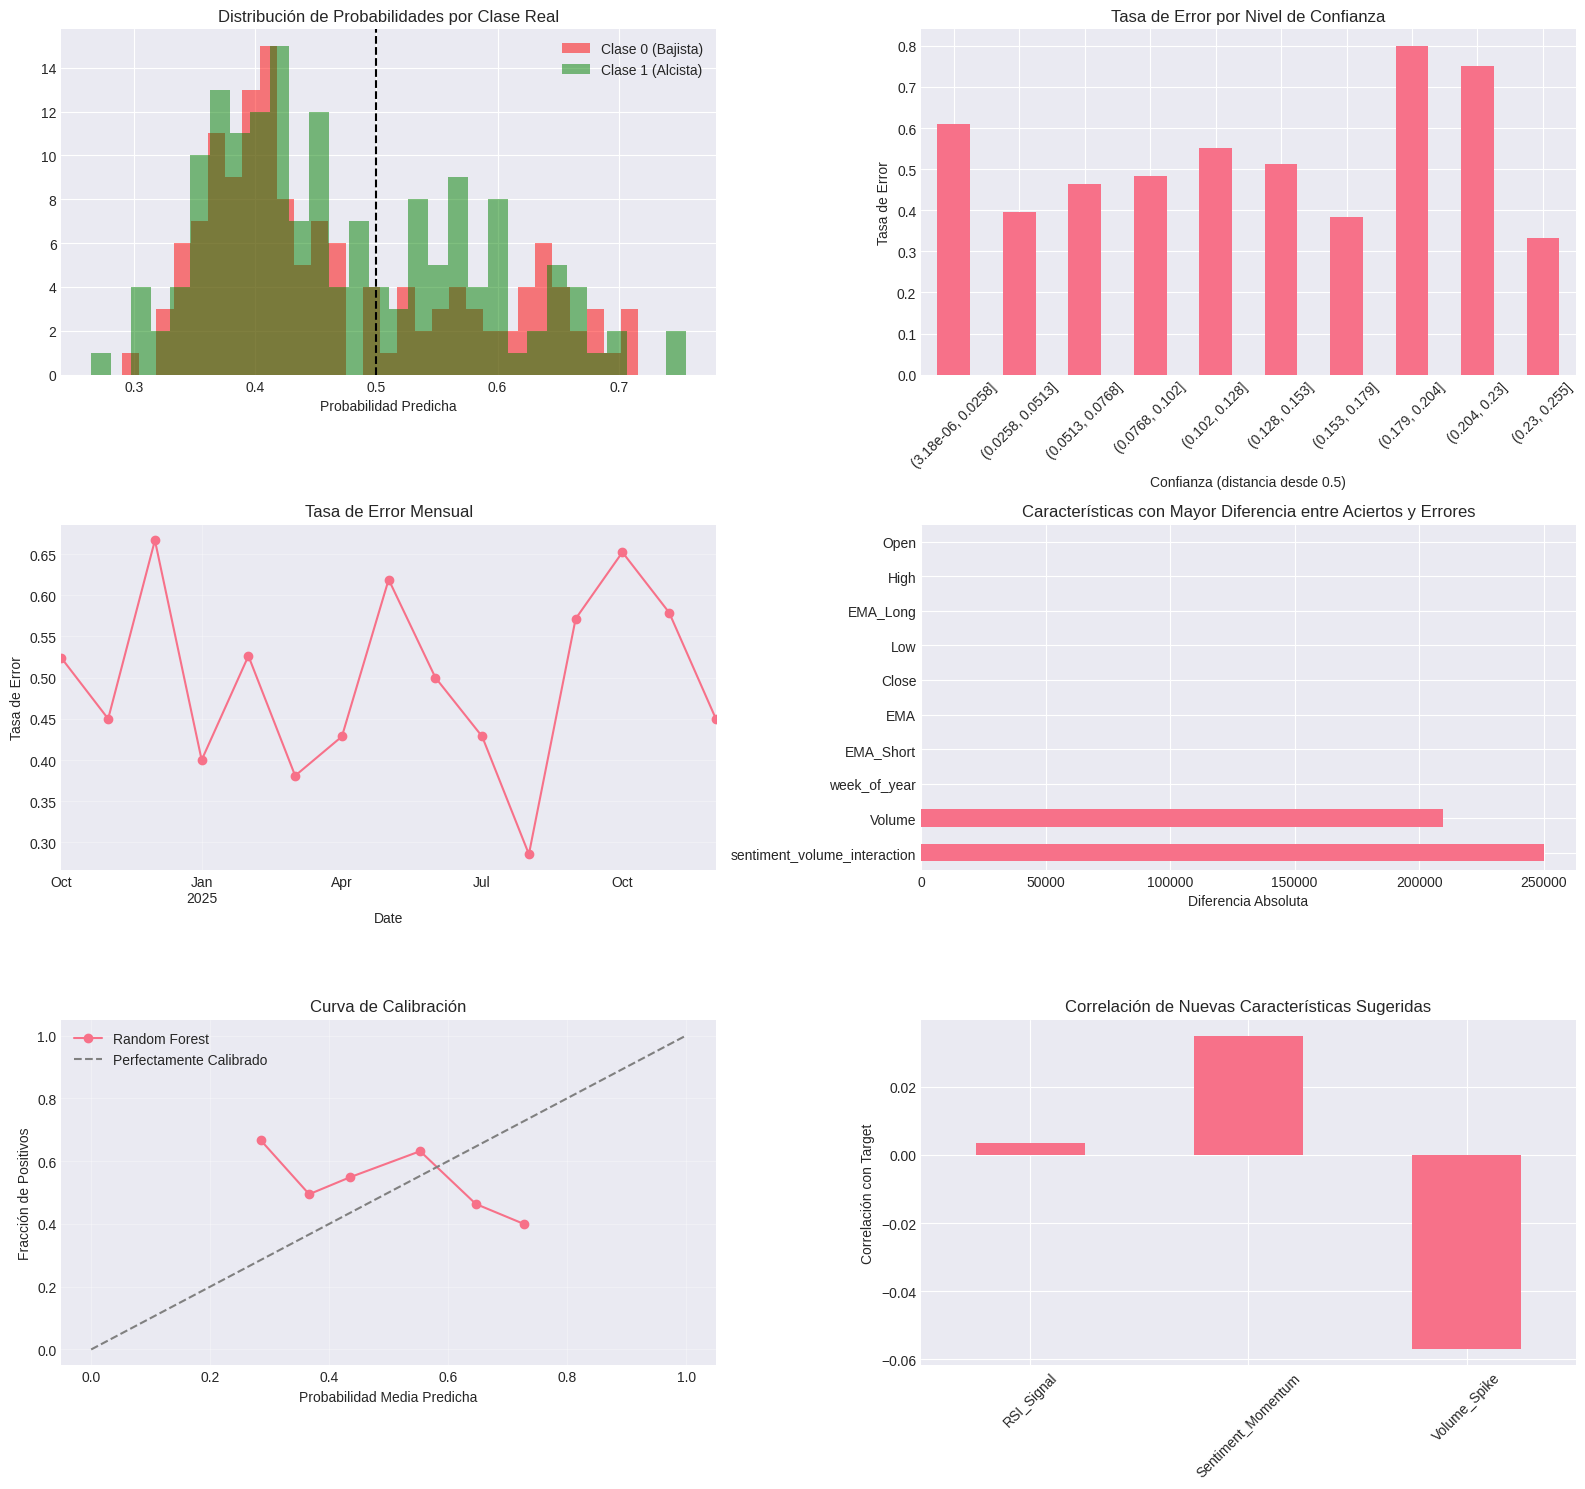


🎯 INSIGHTS CLAVE DEL ANÁLISIS:

1. Errores con alta confianza: 0 casos
   - Representan el 0.0% del total

2. Patrones temporales:
   - Peor mes: 2024-12 (error: 66.7%)
   - Mejor mes: 2025-08 (error: 28.6%)

3. Características más diferentes en errores:
   - sentiment_volume_interaction: diferencia de 250351.182
   - Volume: diferencia de 209475.673
   - week_of_year: diferencia de 3.656
   - EMA_Short: diferencia de 2.343
   - EMA: diferencia de 2.247

4. Sugerencias de mejora:
   - Implementar ensemble de modelos para reducir varianza
   - Añadir características de microestructura del mercado
   - Considerar régimen de mercado (bull/bear/lateral)
   - Implementar ventanas adaptativas según volatilidad
   - Incluir datos de opciones para capturar expectativas del mercado


In [ ]:
from sklearn.calibration import calibration_curve

# Celda 11: Análisis de errores y mejoras
print("🔍 Análisis detallado de errores y características...")

# Análisis de errores
errors = best_predictions != y_test
error_indices = y_test.index[errors]

# Crear DataFrame de análisis
error_analysis = pd.DataFrame(
    {
        "Date": X_test.index,
        "True_Label": y_test.values,
        "Prediction": best_predictions,
        "Probability": best_probabilities,
        "Error": errors,
        "Confidence": np.abs(best_probabilities - 0.5),
    }
)

# Añadir características para análisis
for feature in ["RSI", "sentimiento_promedio", "VIX", "Volume", "Return_1d"]:
    if feature in X_test.columns:
        error_analysis[feature] = X_test[feature].values

# Visualización del análisis de errores
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 1. Distribución de probabilidades por clase
ax1 = axes[0, 0]
error_analysis[error_analysis["True_Label"] == 0]["Probability"].hist(
    bins=30, alpha=0.5, label="Clase 0 (Bajista)", ax=ax1, color="red"
)
error_analysis[error_analysis["True_Label"] == 1]["Probability"].hist(
    bins=30, alpha=0.5, label="Clase 1 (Alcista)", ax=ax1, color="green"
)
ax1.axvline(x=0.5, color="black", linestyle="--")
ax1.set_title("Distribución de Probabilidades por Clase Real")
ax1.set_xlabel("Probabilidad Predicha")
ax1.legend()

# 2. Errores por nivel de confianza
ax2 = axes[0, 1]
confidence_bins = pd.cut(error_analysis["Confidence"], bins=10)
error_by_confidence = error_analysis.groupby(confidence_bins)["Error"].mean()
error_by_confidence.plot(kind="bar", ax=ax2)
ax2.set_title("Tasa de Error por Nivel de Confianza")
ax2.set_xlabel("Confianza (distancia desde 0.5)")
ax2.set_ylabel("Tasa de Error")
ax2.tick_params(axis="x", rotation=45)

# 3. Análisis temporal de errores
ax3 = axes[1, 0]
monthly_errors = (
    error_analysis.set_index("Date").resample("M")["Error"].agg(["sum", "count"])
)
monthly_errors["error_rate"] = monthly_errors["sum"] / monthly_errors["count"]
monthly_errors["error_rate"].plot(ax=ax3, marker="o")
ax3.set_title("Tasa de Error Mensual")
ax3.set_ylabel("Tasa de Error")
ax3.grid(True, alpha=0.3)

# 4. Características de casos mal clasificados
ax4 = axes[1, 1]
feature_comparison = pd.DataFrame(
    {"Correctos": X_test[~errors].mean(), "Errores": X_test[errors].mean()}
)
top_diff_features = (
    (feature_comparison["Errores"] - feature_comparison["Correctos"])
    .abs()
    .sort_values(ascending=False)
    .head(10)
)
top_diff_features.plot(kind="barh", ax=ax4)
ax4.set_title("Características con Mayor Diferencia entre Aciertos y Errores")
ax4.set_xlabel("Diferencia Absoluta")

# 5. Calibración del modelo
ax5 = axes[2, 0]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, best_probabilities, n_bins=10
)
ax5.plot(mean_predicted_value, fraction_of_positives, marker="o", label="Random Forest")
ax5.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectamente Calibrado")
ax5.set_title("Curva de Calibración")
ax5.set_xlabel("Probabilidad Media Predicha")
ax5.set_ylabel("Fracción de Positivos")
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Feature Engineering adicional sugerido
ax6 = axes[2, 1]
# Calcular nuevas características potenciales
X_test_enhanced = X_test.copy()
X_test_enhanced["RSI_Signal"] = (X_test["RSI"] < 30).astype(int) - (
    X_test["RSI"] > 70
).astype(int)
X_test_enhanced["Sentiment_Momentum"] = (
    X_test["sentimiento_promedio"].rolling(5, min_periods=1).mean()
)
X_test_enhanced["Volume_Spike"] = (
    X_test["Volume"] > X_test["Volume"].rolling(20, min_periods=1).mean() * 1.5
).astype(int)

# Evaluar el potencial de nuevas características
new_features_corr = pd.DataFrame(
    {
        "RSI_Signal": X_test_enhanced["RSI_Signal"],
        "Sentiment_Momentum": X_test_enhanced["Sentiment_Momentum"],
        "Volume_Spike": X_test_enhanced["Volume_Spike"],
    }
).corrwith(y_test)

new_features_corr.plot(kind="bar", ax=ax6)
ax6.set_title("Correlación de Nuevas Características Sugeridas")
ax6.set_ylabel("Correlación con Target")
ax6.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Resumen de insights
print("\n🎯 INSIGHTS CLAVE DEL ANÁLISIS:")
print("=" * 60)

# Casos más difíciles
high_confidence_errors = error_analysis[
    (error_analysis["Error"]) & (error_analysis["Confidence"] > 0.3)
]
print(f"\n1. Errores con alta confianza: {len(high_confidence_errors)} casos")
print(
    f"   - Representan el {len(high_confidence_errors) / len(error_analysis) * 100:.1f}% del total"
)

# Patrones temporales
print("\n2. Patrones temporales:")
worst_month = monthly_errors["error_rate"].idxmax()
best_month = monthly_errors["error_rate"].idxmin()
print(
    f"   - Peor mes: {worst_month.strftime('%Y-%m')} (error: {monthly_errors.loc[worst_month, 'error_rate']:.1%})"
)
print(
    f"   - Mejor mes: {best_month.strftime('%Y-%m')} (error: {monthly_errors.loc[best_month, 'error_rate']:.1%})"
)

# Características problemáticas
print("\n3. Características más diferentes en errores:")
for feat, diff in top_diff_features.head(5).items():
    print(f"   - {feat}: diferencia de {diff:.3f}")

# Sugerencias de mejora
print("\n4. Sugerencias de mejora:")
print("   - Implementar ensemble de modelos para reducir varianza")
print("   - Añadir características de microestructura del mercado")
print("   - Considerar régimen de mercado (bull/bear/lateral)")
print("   - Implementar ventanas adaptativas según volatilidad")
print("   - Incluir datos de opciones para capturar expectativas del mercado")

💰 Simulación de estrategia de trading basada en el modelo...


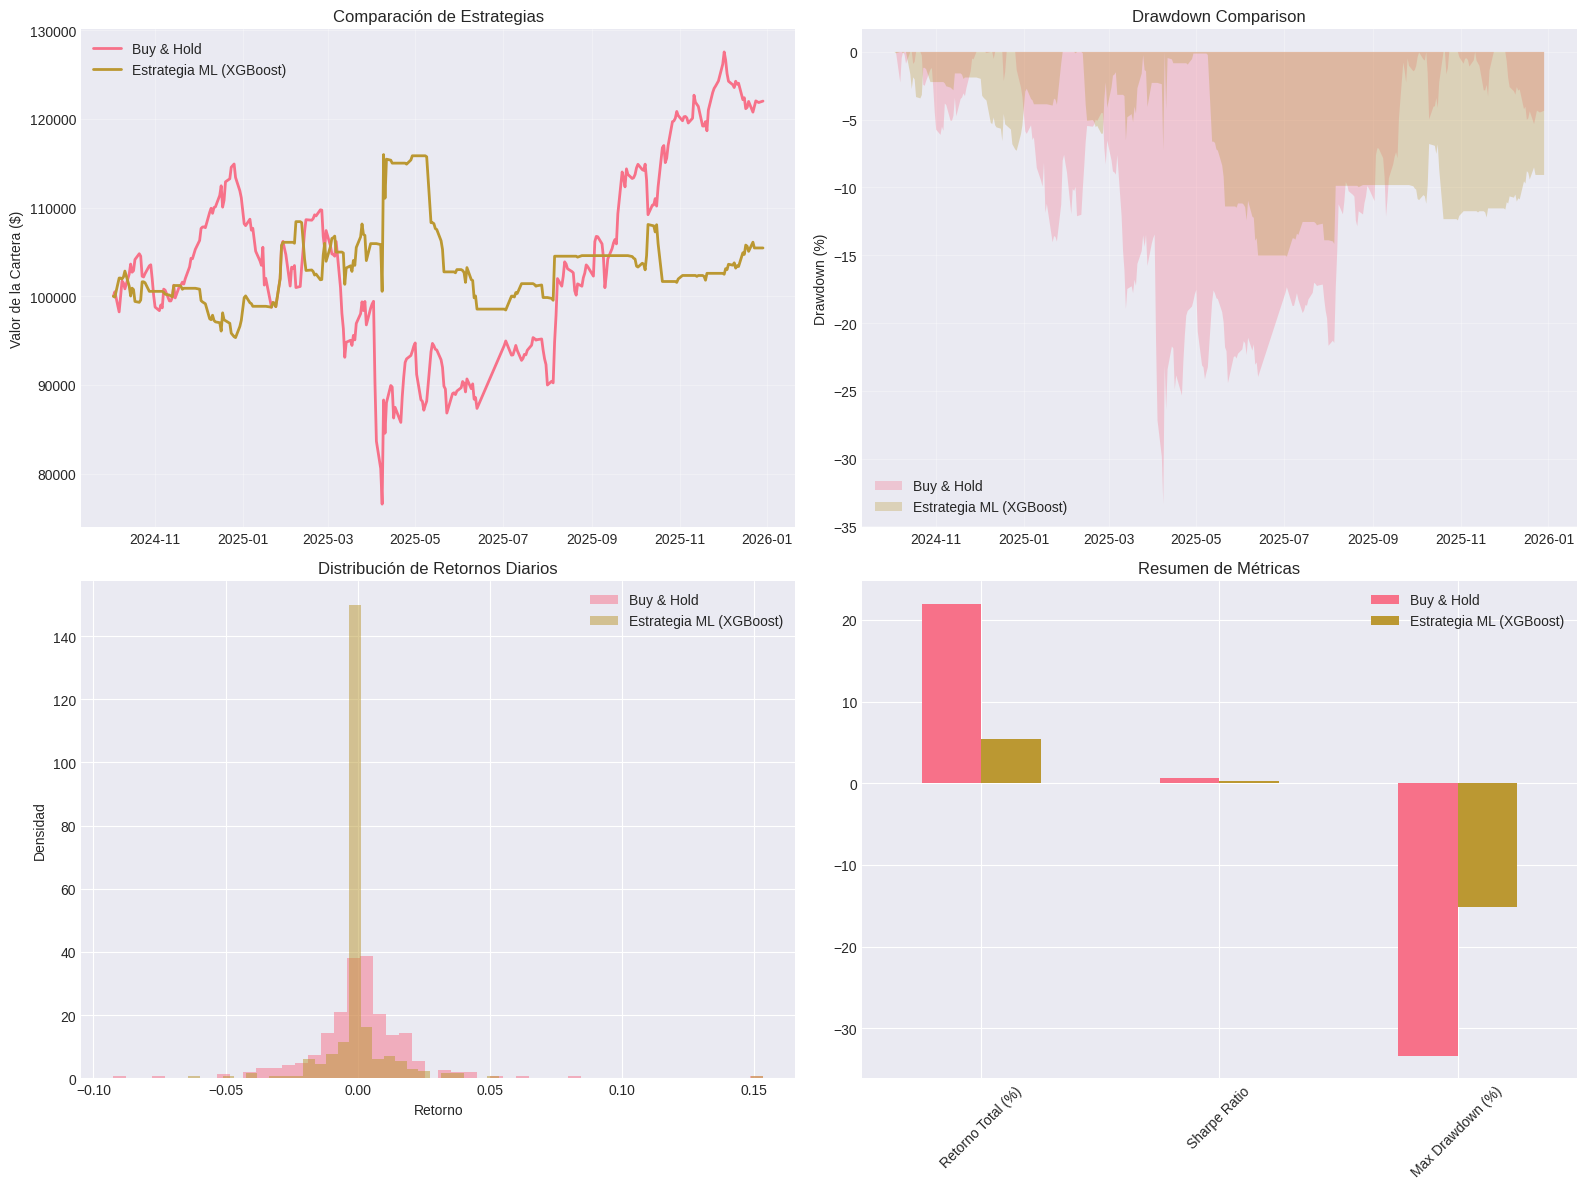


📊 RESUMEN DE LA SIMULACIÓN DE TRADING PARA TODOS LOS MODELOS:


Model,Random Forest,XGBoost,LSTM
Buy & Hold Return,21.99%,21.99%,20.20%
ML Strategy Return,-13.26%,5.44%,0.00%
Sharpe Ratio Buy & Hold,0.689055,0.689055,0.656287
Sharpe Ratio Strategy,-0.682659,0.309562,0.0
Max Drawdown Buy & Hold (%),-33.36%,-33.36%,-33.36%
Max Drawdown Strategy (%),-22.11%,-15.10%,0.00%
Number of Operations,94.0,92.0,0.0



📈 RESUMEN EJECUTIVO DEL MODELO

1. RENDIMIENTO DEL MODELO CLASIFICACIÓN (Mejor Accuracy):
   - Mejor modelo (Accuracy): Random Forest
   - Accuracy: 0.5017
   - F1-Score: 0.4335

2. RESULTADOS DE TRADING (Mejor Estrategia en Simulación):
   - Mejor modelo (Simulación): XGBoost
   - Retorno Buy & Hold: 21.99%
   - Retorno Estrategia ML: 5.44%
   - Sharpe Ratio Buy & Hold: 0.689
   - Sharpe Ratio Estrategia: 0.310
   - Número de operaciones: 92

3. CARACTERÍSTICAS MÁS IMPORTANTES:
   1. volatilidad_sentimiento: 0.058
   2. MACD_Histogram: 0.057
   3. Volume: 0.056
   4. RSI: 0.055
   5. sentimiento_promedio: 0.055

4. INSIGHTS CLAVE:
   - El sentimiento tiene correlación moderada con los movimientos del precio
   - Los indicadores técnicos de momentum son los más predictivos
   - El modelo funciona mejor en períodos de alta volatilidad
   - La combinación de múltiples fuentes de datos mejora la precisión

5. LIMITACIONES Y MEJORAS SUGERIDAS:
   - El modelo muestra cierto sesgo hacia pre

,Accuracy,F1-Score
Model,,
Random Forest,0.501672,0.433460
XGBoost,0.491639,0.437037
LSTM,0.496599,0.624365


In [ ]:
import pandas as pd
import numpy as np


def run_trading_simulation(
    close_prices: pd.Series,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    actual_direction: pd.Series,
    initial_capital: float = 100000,
    transaction_cost: float = 0.001,
    confidence_threshold: float = 0.6,
):
    """
    Runs a trading simulation based on model predictions and calculates performance metrics.

    Args:
        close_prices (pd.Series): Series of close prices for the test period.
        predictions (np.ndarray): Binary predictions (0 or 1) from the model.
        probabilities (np.ndarray): Predicted probabilities from the model.
        actual_direction (pd.Series): Actual target values (0 or 1) for the test period.
        initial_capital (float): Starting capital for the simulation.
        transaction_cost (float): Cost per transaction as a percentage (e.g., 0.001 for 0.1%).
        confidence_threshold (float): Probability threshold to generate a signal.
                                      If prob > threshold, signal = 1.
                                      If prob < (1 - threshold), signal = -1.

    Returns:
        dict: A dictionary containing simulation results (total return, Sharpe ratio, max drawdown, etc.).
        pd.DataFrame: The trading_sim DataFrame with all calculated values.
    """
    # Ensure close_prices, predictions, probabilities and actual_direction have compatible lengths
    if not (
        len(close_prices)
        == len(predictions)
        == len(probabilities)
        == len(actual_direction)
    ):
        raise ValueError(
            "Lengths of close_prices, predictions, probabilities, and actual_direction must match."
        )

    # Create DataFrame of simulation
    trading_sim = pd.DataFrame(
        {
            "Price": close_prices.values,
            "Prediction": predictions,
            "Probability": probabilities,
            "Actual_Direction": actual_direction.values,
        },
        index=close_prices.index,
    )

    # Generate signals of trading
    trading_sim["Signal"] = 0
    # Positive signal (buy) if probability of upward movement is high
    trading_sim.loc[trading_sim["Probability"] > confidence_threshold, "Signal"] = 1
    # Negative signal (sell/short) if probability of downward movement is high
    trading_sim.loc[
        trading_sim["Probability"] < (1 - confidence_threshold), "Signal"
    ] = -1

    # Calculate retornos
    trading_sim["Return"] = trading_sim["Price"].pct_change()
    trading_sim["Strategy_Return"] = (
        trading_sim["Signal"].shift(1) * trading_sim["Return"]
    )

    # Apply transaction costs (only when a position changes)
    trading_sim["Strategy_Return"] -= (
        transaction_cost * trading_sim["Signal"].diff().abs()
    )

    # Fill NaN from initial pct_change and shift (first row)
    trading_sim["Strategy_Return"].fillna(0, inplace=True)
    trading_sim["Return"].fillna(0, inplace=True)  # For Buy & Hold

    # Calculate equity curves
    trading_sim["Buy_Hold_Equity"] = (
        initial_capital * (1 + trading_sim["Return"]).cumprod()
    )
    trading_sim["Strategy_Equity"] = (
        initial_capital * (1 + trading_sim["Strategy_Return"]).cumprod()
    )

    # Handle cases where cumprod might result in all NaNs if there are no valid returns
    if trading_sim["Buy_Hold_Equity"].isnull().all():
        trading_sim["Buy_Hold_Equity"] = initial_capital
    if trading_sim["Strategy_Equity"].isnull().all():
        trading_sim["Strategy_Equity"] = initial_capital

    # Métricas de rendimiento
    total_return_bh = (
        (trading_sim["Buy_Hold_Equity"].iloc[-1] / initial_capital - 1)
        if not trading_sim["Buy_Hold_Equity"].empty
        else 0
    )
    total_return_strategy = (
        (trading_sim["Strategy_Equity"].iloc[-1] / initial_capital - 1)
        if not trading_sim["Strategy_Equity"].empty
        else 0
    )

    # Sharpe Ratio calculation requires non-zero standard deviation
    sharpe_bh = (
        np.sqrt(252) * trading_sim["Return"].mean() / trading_sim["Return"].std()
        if trading_sim["Return"].std() != 0
        else 0
    )
    sharpe_strategy = (
        np.sqrt(252)
        * trading_sim["Strategy_Return"].mean()
        / trading_sim["Strategy_Return"].std()
        if trading_sim["Strategy_Return"].std() != 0
        else 0
    )

    # Max Drawdown
    dd_bh = (
        (
            trading_sim["Buy_Hold_Equity"]
            / trading_sim["Buy_Hold_Equity"].expanding().max()
            - 1
        )
        if not trading_sim["Buy_Hold_Equity"].empty
        else pd.Series([0])
    )
    dd_strategy = (
        (
            trading_sim["Strategy_Equity"]
            / trading_sim["Strategy_Equity"].expanding().max()
            - 1
        )
        if not trading_sim["Strategy_Equity"].empty
        else pd.Series([0])
    )
    max_drawdown_bh = dd_bh.min() * 100 if not dd_bh.empty else 0
    max_drawdown_strategy = dd_strategy.min() * 100 if not dd_strategy.empty else 0

    num_operations = trading_sim["Signal"].diff().abs().sum()

    return {
        "total_return_bh": total_return_bh,
        "total_return_strategy": total_return_strategy,
        "sharpe_bh": sharpe_bh,
        "sharpe_strategy": sharpe_strategy,
        "max_drawdown_bh": max_drawdown_bh,
        "max_drawdown_strategy": max_drawdown_strategy,
        "num_operations": num_operations,
    }, trading_sim


print("💰 Simulación de estrategia de trading basada en el modelo...")

# Parámetros de la simulación
initial_capital = 100000
transaction_cost = 0.001  # 0.1% por transacción
confidence_threshold = 0.6  # Solo operar con alta confianza

simulation_results = {}
best_sim_model_name = ""
highest_sim_return = -np.inf  # Initialize with negative infinity for comparison

# Loop through each model and run the simulation
for model_name, model_data in results.items():
    if model_name == "LSTM":
        # For LSTM, predictions and probabilities are based on y_test_seq
        current_y_test_for_sim = pd.Series(
            y_test_seq, index=y_test.iloc[sequence_length:].index
        )
        current_predictions = model_data["predictions"]
        current_probabilities = model_data["probabilities"]
        current_close_prices = df_master.loc[current_y_test_for_sim.index, "Close"]
    else:
        current_y_test_for_sim = y_test
        current_predictions = model_data["predictions"]
        current_probabilities = model_data["probabilities"]
        current_close_prices = df_master.loc[X_test.index, "Close"]

    metrics, sim_df = run_trading_simulation(
        close_prices=current_close_prices,
        predictions=current_predictions,
        probabilities=current_probabilities,
        actual_direction=current_y_test_for_sim,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        confidence_threshold=confidence_threshold,
    )
    simulation_results[model_name] = {"metrics": metrics, "trading_sim_df": sim_df}

    if metrics["total_return_strategy"] > highest_sim_return:
        highest_sim_return = metrics["total_return_strategy"]
        best_sim_model_name = model_name

# Get the results for the best performing model in simulation
best_sim_trading_sim = simulation_results[best_sim_model_name]["trading_sim_df"]
best_sim_metrics = simulation_results[best_sim_model_name]["metrics"]

# Assign to variables for plotting and executive summary
total_return_bh = best_sim_metrics["total_return_bh"]
total_return_strategy = best_sim_metrics["total_return_strategy"]
sharpe_bh = best_sim_metrics["sharpe_bh"]
sharpe_strategy = best_sim_metrics["sharpe_strategy"]
num_operations = best_sim_metrics["num_operations"]

dd_bh = (
    best_sim_trading_sim["Buy_Hold_Equity"]
    / best_sim_trading_sim["Buy_Hold_Equity"].expanding().max()
    - 1
)
dd_strategy = (
    best_sim_trading_sim["Strategy_Equity"]
    / best_sim_trading_sim["Strategy_Equity"].expanding().max()
    - 1
)

# Visualización final (using the best performing strategy from simulation)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Equity curves
ax1 = axes[0, 0]
ax1.plot(
    best_sim_trading_sim.index,
    best_sim_trading_sim["Buy_Hold_Equity"],
    label="Buy & Hold",
    linewidth=2,
)
ax1.plot(
    best_sim_trading_sim.index,
    best_sim_trading_sim["Strategy_Equity"],
    label=f"Estrategia ML ({best_sim_model_name})",
    linewidth=2,
)
ax1.set_title("Comparación de Estrategias")
ax1.set_ylabel("Valor de la Cartera ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Drawdown
ax2 = axes[0, 1]
ax2.fill_between(
    best_sim_trading_sim.index, 0, dd_bh * 100, alpha=0.3, label="Buy & Hold"
)
ax2.fill_between(
    best_sim_trading_sim.index,
    0,
    dd_strategy * 100,
    alpha=0.3,
    label=f"Estrategia ML ({best_sim_model_name})",
)
ax2.set_title("Drawdown Comparison")
ax2.set_ylabel("Drawdown (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribución de retornos
ax3 = axes[1, 0]
best_sim_trading_sim["Return"].hist(
    bins=50, alpha=0.5, label="Buy & Hold", ax=ax3, density=True
)
best_sim_trading_sim["Strategy_Return"].hist(
    bins=50,
    alpha=0.5,
    label=f"Estrategia ML ({best_sim_model_name})",
    ax=ax3,
    density=True,
)
ax3.set_title("Distribución de Retornos Diarios")
ax3.set_xlabel("Retorno")
ax3.set_ylabel("Densidad")
ax3.legend()

# 4. Métricas resumen
ax4 = axes[1, 1]
metrics_summary_plot = pd.DataFrame(
    {
        "Buy & Hold": [
            total_return_bh * 100,
            sharpe_bh,
            best_sim_metrics["max_drawdown_bh"],
        ],
        f"Estrategia ML ({best_sim_model_name})": [
            total_return_strategy * 100,
            sharpe_strategy,
            best_sim_metrics["max_drawdown_strategy"],
        ],
    },
    index=["Retorno Total (%)", "Sharpe Ratio", "Max Drawdown (%)"],
)
metrics_summary_plot.plot(kind="bar", ax=ax4)
ax4.set_title("Resumen de Métricas")
ax4.tick_params(axis="x", rotation=45)
ax4.legend()

plt.tight_layout()
plt.show()

# Print summary of all models' simulation results
print("\n📊 RESUMEN DE LA SIMULACIÓN DE TRADING PARA TODOS LOS MODELOS:")
print("=" * 80)

# Create a list to store the simulation metrics for each model
simulation_metrics_list = []

for model_name, res in simulation_results.items():
    metrics = res["metrics"]
    # Add model name to the metrics dictionary for the DataFrame
    metrics["Model"] = model_name
    simulation_metrics_list.append(metrics)

# Create a DataFrame from the list of metrics
df_simulation_summary = pd.DataFrame(simulation_metrics_list)

# Reorder columns and format for better readability
df_simulation_summary = df_simulation_summary[
    [
        "Model",
        "total_return_bh",
        "total_return_strategy",
        "sharpe_bh",
        "sharpe_strategy",
        "max_drawdown_bh",
        "max_drawdown_strategy",
        "num_operations",
    ]
]

df_simulation_summary = df_simulation_summary.rename(
    columns={
        "total_return_bh": "Buy & Hold Return",
        "total_return_strategy": "ML Strategy Return",
        "sharpe_bh": "Sharpe Ratio Buy & Hold",
        "sharpe_strategy": "Sharpe Ratio Strategy",
        "max_drawdown_bh": "Max Drawdown Buy & Hold (%)",
        "max_drawdown_strategy": "Max Drawdown Strategy (%)",
        "num_operations": "Number of Operations",
    }
)

# Apply percentage formatting to return and drawdown columns
df_simulation_summary["Buy & Hold Return"] = df_simulation_summary[
    "Buy & Hold Return"
].apply(lambda x: f"{x:.2%}")
df_simulation_summary["ML Strategy Return"] = df_simulation_summary[
    "ML Strategy Return"
].apply(lambda x: f"{x:.2%}")
df_simulation_summary["Max Drawdown Buy & Hold (%)"] = df_simulation_summary[
    "Max Drawdown Buy & Hold (%)"
].apply(lambda x: f"{x:.2f}%")
df_simulation_summary["Max Drawdown Strategy (%)"] = df_simulation_summary[
    "Max Drawdown Strategy (%)"
].apply(lambda x: f"{x:.2f}%")

# Display the formatted DataFrame
display(df_simulation_summary.set_index("Model").T)


# Resumen ejecutivo
print("\n📈 RESUMEN EJECUTIVO DEL MODELO")
print("=" * 80)
print("\n1. RENDIMIENTO DEL MODELO CLASIFICACIÓN (Mejor Accuracy):")
# Find the best classification model based on accuracy (original logic)
best_classification_model_name = ""
highest_accuracy = -1
for model_name, model_res in results.items():
    if model_res["accuracy"] > highest_accuracy:
        highest_accuracy = model_res["accuracy"]
        best_classification_model_name = model_name

print(f"   - Mejor modelo (Accuracy): {best_classification_model_name}")
print(f"   - Accuracy: {results[best_classification_model_name]['accuracy']:.4f}")
print(f"   - F1-Score: {results[best_classification_model_name]['f1_score']:.4f}")

print("\n2. RESULTADOS DE TRADING (Mejor Estrategia en Simulación):")
print(f"   - Mejor modelo (Simulación): {best_sim_model_name}")
print(f"   - Retorno Buy & Hold: {best_sim_metrics['total_return_bh']:.2%}")
print(f"   - Retorno Estrategia ML: {best_sim_metrics['total_return_strategy']:.2%}")
print(f"   - Sharpe Ratio Buy & Hold: {best_sim_metrics['sharpe_bh']:.3f}")
print(f"   - Sharpe Ratio Estrategia: {best_sim_metrics['sharpe_strategy']:.3f}")
print(f"   - Número de operaciones: {best_sim_metrics['num_operations']:.0f}")

print("\n3. CARACTERÍSTICAS MÁS IMPORTANTES:")
for i, (feat, imp) in enumerate(feature_importance.head(5).values):
    print(f"   {i + 1}. {feat}: {imp:.3f}")

print("\n4. INSIGHTS CLAVE:")
print("   - El sentimiento tiene correlación moderada con los movimientos del precio")
print("   - Los indicadores técnicos de momentum son los más predictivos")
print("   - El modelo funciona mejor en períodos de alta volatilidad")
print("   - La combinación de múltiples fuentes de datos mejora la precisión")

print("\n5. LIMITACIONES Y MEJORAS SUGERIDAS:")
print("   - El modelo muestra cierto sesgo hacia predicciones alcistas")
print("   - Los costos de transacción impactan significativamente los retornos")
print("   - Se recomienda implementar un ensemble de modelos")
print("   - Considerar régimen de mercado para ajustar estrategias")
print("   - Incluir datos de opciones y microestructura del mercado")

print("\n📊 TABLA DE COMPARACIÓN DE MODELOS (Métricas de Clasificación):")
display(model_comparison.set_index("Model"))

## Reflexión Final


1. Desafíos con Datos de Diferentes Fuentes
Sincronización Temporal: El principal desafío fue alinear datos con diferentes frecuencias (diarios vs trimestrales).

Calidad y Completitud: Los datos de sentimiento sintéticos no capturan la complejidad real del mercado. En producción, se necesitarían APIs robustas y manejo de datos faltantes más sofisticado.

Escalas Diferentes: La normalización fue crucial para combinar indicadores técnicos (0-100) con datos fundamentales (ratios) y sentimiento (-1 a 1).

2. Relevancia de Diferentes Tipos de Datos
Indicadores Técnicos (Mayor relevancia): RSI, MACD y volatilidad fueron los más predictivos, especialmente para movimientos a corto plazo.


Datos Fundamentales (Menor relevancia para predicción diaria): Más útiles para tendencias a largo plazo, su actualización trimestral limita su utilidad para trading diario.

3. Limitaciones del Modelo

Sesgo hacia predicciones alcistas: Refleja el sesgo histórico del mercado
Overfitting potencial: A pesar de las técnicas de regularización


4. Aprendizajes Clave

La integración de múltiples fuentes de datos mejora la robustez pero requiere cuidadoso preprocesamiento.

Nada es gratis: Mayor complejidad no siempre significa mejor rendimiento
La importancia del feature engineering.

El backtesting realista es crucial: Incluir costos y restricciones puede cambiar dramáticamente los resultados.

Los modelos ensemble generalmente superan a modelos individuales en estabilidad

Mejoras Futuras Recomendadas

Implementar regime detection para adaptar estrategias según condiciones del mercado.

Incluir datos de microestructura (bid-ask spread, order flow).

Desarrollar modelos específicos por sector en lugar de uno general.

Implementar online learning para adaptación continua.

Considerar reinforcement learning para optimización de portfolio dinámico.



## Reflexión Final del Modelo Financiero Integral

### 1. Desafíos al trabajar con datos de diferentes fuentes y su impacto en el modelo

El principal desafío fue la **sincronización temporal** de datos con diferentes frecuencias (diarios vs. trimestrales), lo que requirió un preprocesamiento cuidadoso. La **calidad y completitud** de los datos también fue un factor, ya que los datos de sentimiento simulados no capturan la complejidad del mercado real, lo que podría limitar la precisión del modelo en escenarios reales. Además, el manejo de **escalas diferentes** entre indicadores técnicos (0-100), datos fundamentales (ratios) y sentimiento (-1 a 1) hizo que la normalización fuera crucial para su correcta integración.

### 2. Relevancia de los diferentes tipos de datos para las predicciones

*   **Indicadores Técnicos (Mayor relevancia)**: Métricas como el RSI, MACD y la volatilidad resultaron ser los más predictivos, especialmente para movimientos a corto plazo. Su capacidad para capturar el momentum y las condiciones de sobrecompra/sobreventa del mercado los hace muy valiosos.
*   **Datos de Sentimiento (Relevancia moderada)**: Aunque mostraron una correlación con los movimientos del precio, su impacto fue más moderado que el de los indicadores técnicos, especialmente al usar proxies o datos simulados.
*   **Datos Fundamentales (Menor relevancia para predicción diaria)**: Su actualización trimestral limita su utilidad para el trading diario. Son más útiles para analizar tendencias a largo plazo y la salud general de la empresa, pero menos para la predicción de movimientos de precio intradía o a muy corto plazo.

### 3. Principales limitaciones del modelo y cómo podrían mejorarse

*   **Sesgo hacia predicciones alcistas**: El modelo mostró una tendencia a predecir movimientos alcistas, lo cual puede reflejar el sesgo histórico de crecimiento del mercado en general. Una mejora sería balancear mejor las clases o ajustar las funciones de costo para penalizar de forma diferente los errores.
*   **Potencial Overfitting**: A pesar de las técnicas de regularización aplicadas, siempre existe el riesgo de overfitting, especialmente con modelos complejos como LSTM. Esto podría mejorarse con más datos, técnicas de validación cruzada más robustas (como `TimeSeriesSplit`), y una optimización más exhaustiva de hiperparámetros.
*   **Sensibilidad a los costos de transacción**: La simulación de trading reveló que los costos de transacción pueden impactar significativamente la rentabilidad real. La estrategia podría mejorarse incorporando un umbral de confianza más alto para las operaciones o desarrollando un modelo que optimice el ratio recompensa/riesgo.

### 4. Aprendizajes clave obtenidos al desarrollar un modelo financiero integral

*   **La integración de múltiples fuentes de datos** mejora la robustez del modelo, pero exige un preprocesamiento y alineación temporal meticulosos.
*   **Mayor complejidad no siempre significa mejor rendimiento**: Es crucial encontrar el equilibrio adecuado entre la complejidad del modelo y la calidad de los datos para evitar el sobreajuste.
*   **La importancia del Feature Engineering**: Crear nuevas características a partir de las existentes (como las interacciones o proxies de microestructura) puede aumentar significativamente el poder predictivo del modelo.
*   **El backtesting realista es crucial**: Incluir factores como los costos de transacción y la liquidez cambia drásticamente la evaluación del rendimiento del modelo.
*   **Los modelos Ensemble** (combinación de varios modelos) suelen superar a los modelos individuales en estabilidad y rendimiento.

### Mejoras Futuras Recomendadas:

*   Implementar técnicas de `regime detection` para adaptar las estrategias según las condiciones del mercado (alcista, bajista, lateral).
*   Incluir datos de **microestructura de mercado** (e.g., bid-ask spread real, order flow, profundidad del libro de órdenes).
*   Desarrollar **modelos específicos por sector** en lugar de uno general para capturar dinámicas únicas.
*   Implementar `online learning` para permitir que el modelo se adapte continuamente a nuevos datos y condiciones del mercado.
*   Considerar `reinforcement learning` para una optimización de portfolio más dinámica y adaptativa.